# Temporal Decay (Frozen Schema) -- EDA

Visualises `run_temporal_decay_experiment`
(`thesis.system_eval.temporal_decay`). One schema+model is mined/fit once on
the **source window's train split** (here `source_split_mode="baseline_split"`
-- W_src = the CSCAS baseline's own train period) and **frozen**: schema,
model and decision threshold. It is then walked forward one window at a time
to the end of the timeline. `h=0` is W_src's own held-out test split; every
horizon after that is a fully external future window.

**Three feature sets** are compared head to head (all frozen, all walked the
same way):

| `feature_set` | what it is |
|---|---|
| `baseline`   | the 5 deployment-realistic base columns only |
| `symbolic`   | base + a schema mined on W_src (6 mining settings) |
| `cscas_full` | the CSCAS paper's own ~41 columns (base + SCAS + Similarity + 33 attr-similarity). A **non-deployable reference ceiling** -- SCAS/Similarity come from CSCAS's offline pipeline. `scas` is dropped for the one-class models. |
| `cscas_full_symbolic` | `cscas_full` columns + the mined `symbolic` layer (shared base columns encoded once). |

**Four models**: `logreg`, `xgboost` (supervised) and `iforest`, `ocsvm`
(one-class, Platt-scaled to an attack probability). All frozen, all walked
identically.

**Explanations.** SHAP + LIME signed importances are logged for every schema
feature at every horizon, against a background sample frozen from W_src. The
one-class models have **no analytic SHAP explainer**, so this run computes
**LIME for all four models and SHAP only for `logreg`/`xgboost`**. LIME is
therefore the common basis for any cross-model comparison.

**Novelty.** Every horizon row also carries alert-group novelty vs. W_src's
train span, at two grains: the `raw_items` token-set (`*_items`) and the
`(category, ruleset, proto)` tuple (`*_crp`). These are schema/model
independent -- one series per granularity.

Sections:
- **§1** metric decay vs. horizon -- the three schemas, per model
- **§2** decay-summary table (h=0 vs. last horizon)
- **§3** per-horizon feature-importance heatmaps (per model, per schema)
- **§4** importance **stability** vs. h=0 -- the cross-model-comparable view
- **§5** decay **rate / acceleration** vs. how much novel traffic each window brings

In [154]:
from __future__ import annotations

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from matplotlib.lines import Line2D

from thesis.experiments._shared import METRIC_COLS
from thesis.paths import RESULTS_DIR, ROOT

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

## Config

Edit and re-run -- nothing past the loader cell needs changing.

In [155]:
SCENARIO = "cscas"
RUN_ID = None          # None -> latest run dir for SCENARIO; or "20260914_172854"

PRIMARY_METRIC = "f1"  # §1 first panel, §2 sort, §5 default rate metric
GRANULARITY = None      # None -> finest (most horizons); or pin one the run used

# §1 symbolic band: symbolic has one curve per mining setting. Show them as a
# median line + inter-quartile band instead of 6 separate lines.
SYMBOLIC_AS_BAND = True

# §3 / §4: which symbolic mining setting to use where a single schema is
# needed (heatmaps, per-schema feature lists). None -> first available.
MINING_SETTING = None

# Every figure below is also written here (see save_fig() in Shared
# helpers), named <scenario>_<section>_<plot>_<params...>.png so the
# model/granularity/metric/feature_set/etc that produced it is legible
# from the filename alone.
IMG_DIR = ROOT / "src/thesis/notebooks/experiments/img/exp1"
SAVE_FIGS = True   # False to skip writing PNGs (e.g. quick iteration)
SAVE_DPI = 150

HEATMAP_TOP_K = 18      # features (rows) per heatmap, by pooled mean |importance|
STABILITY_TOP_K = 10    # top-k set size for the §4 Jaccard-overlap curve

# Keys are the raw feature_set values the run's CSVs actually use -- keep
# these as-is, everything downstream filters against them. FEATURE_SET_LABEL
# is a display-only rename (thesis terminology) applied wherever a
# feature_set is rendered (legend/title/table) via fs_label() below; it's
# never used for filtering, so renaming it can't silently break matching
# against the data the way keying FEATURE_SET_ORDER/COLOR on the display
# names did.
FEATURE_SET_ORDER = ["baseline", "symbolic", "cscas_full", "cscas_full_symbolic"]
FEATURE_SET_COLOR = {"baseline": "#BB5566", "symbolic": "#004488",
                     "cscas_full": "#DDAA33", "cscas_full_symbolic": "#228833"}
FEATURE_SET_LABEL = {"baseline": "base", "symbolic": "base_symbolic",
                     "cscas_full": "full", "cscas_full_symbolic": "full_symbolic"}
# Known models get a fixed colour so figures agree run to run; anything
# else present in the loaded run (a model added later, e.g. "rf") still
# shows up -- appended in MODELS below with a palette colour -- instead of
# silently vanishing the way a plain membership filter would.
MODEL_ORDER = ["logreg", "xgboost", "rf", "iforest", "ocsvm"]
MODEL_COLOR = dict(zip(MODEL_ORDER, ["#004488", "#66CCEE", "#CCBB44", "#228833", "#EE6677"]))

In [156]:
sweep_dir = RESULTS_DIR / "sys-eval" / "temporal-decay" / SCENARIO
run_dirs = sorted(p for p in sweep_dir.iterdir() if p.is_dir())
run_dir = (sweep_dir / RUN_ID) if RUN_ID else run_dirs[-1]


def _read_csv_maybe_empty(path) -> pd.DataFrame:
    """A metrics-only run writes explanations.csv / lime_fidelity.csv from an
    empty frame (a bare newline) -- pd.read_csv raises EmptyDataError on
    that. Treat it as zero rows."""
    try:
        return pd.read_csv(path, low_memory=False)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


per_horizon = pd.read_csv(run_dir / "per_horizon_results.csv", low_memory=False)
decay_summary = pd.read_csv(run_dir / "decay_summary.csv")
explanations = _read_csv_maybe_empty(run_dir / "explanations.csv")
lime_fidelity = _read_csv_maybe_empty(run_dir / "lime_fidelity.csv")

NOVELTY_COLS = [c for c in per_horizon.columns
                if c.startswith(("n_novel", "frac_novel", "n_new_", "n_groups_win", "n_attack_win"))]
HAS_NOVELTY = bool(NOVELTY_COLS)
HAS_EXPLANATIONS = not explanations.empty

print(f"run: {run_dir.name}")
print(f"  per_horizon : {len(per_horizon):>6} rows")
print(f"  decay_summary: {len(decay_summary):>6} rows")
print(f"  explanations : {len(explanations):>6} rows"
      + ("" if HAS_EXPLANATIONS else "  (none -- §3/§4 will be empty)"))
print(f"  lime_fidelity: {len(lime_fidelity):>6} rows")
print()
print(f"  feature_sets : {sorted(per_horizon['feature_set'].unique())}")
print(f"  models       : {sorted(per_horizon['model'].unique())}")
print(f"  mining setts : {sorted(per_horizon['mining_setting'].dropna().unique())}")
print(f"  granularities: {sorted(per_horizon['granularity'].unique())}")
print(f"  horizons     : 0..{int(per_horizon['horizon_window_index'].max())}")
print(f"  novelty cols : {'yes' if HAS_NOVELTY else 'NO -- older run, §5 overlay disabled'}")
if HAS_EXPLANATIONS:
    cov = (explanations.groupby(['feature_set', 'model'])['method']
           .agg(lambda s: '+'.join(sorted(s.unique()))).unstack())
    print("\n  explanation methods by feature_set x model:")
    print(cov.to_string().replace("\n", "\n  "))

run: 20260919_200100
  per_horizon :    256 rows
  decay_summary:     16 rows
  explanations :  30464 rows
  lime_fidelity:    256 rows

  feature_sets : ['baseline', 'cscas_full', 'cscas_full_symbolic', 'symbolic']
  models       : ['rf', 'xgboost']
  mining setts : ['gr3_md1_mda4_rounds2']
  granularities: [0.05, 0.1]
  horizons     : 0..20
  novelty cols : yes

  explanation methods by feature_set x model:
model                       rf    xgboost
  feature_set                              
  baseline             lime+shap  lime+shap
  cscas_full           lime+shap  lime+shap
  cscas_full_symbolic  lime+shap  lime+shap
  symbolic             lime+shap  lime+shap


## Shared helpers

In [157]:
import re

CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]

IMG_DIR.mkdir(parents=True, exist_ok=True)


def _slugify(*parts) -> str:
    """Join description parts into one filesystem-safe filename stem --
    e.g. _slugify("cscas", "sec1", "decay", "f1", "gran=0.05") ->
    "cscas_sec1_decay_f1_gran_0.05"."""
    bits = []
    for p in parts:
        if p is None or p == "":
            continue
        s = re.sub(r"[^A-Za-z0-9_.=-]+", "_", str(p)).strip("_")
        if s:
            bits.append(s)
    return "_".join(bits)


def save_fig(fig, *name_parts) -> Path | None:
    """Save `fig` to IMG_DIR as <SCENARIO>_<name_parts...>.png (skipped, no-op,
    if SAVE_FIGS is False). Called at the end of every plot_*() function and
    every inline plotting cell below."""
    if not SAVE_FIGS:
        return None
    path = IMG_DIR / f"{_slugify(SCENARIO, *name_parts)}.png"
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight")
    print(f"  saved -> {path.relative_to(ROOT)}")
    return path


def resolve_gran() -> float:
    grans = sorted(per_horizon["granularity"].unique())
    if GRANULARITY is None:
        return grans[0]
    if GRANULARITY not in grans:
        raise ValueError(f"GRANULARITY={GRANULARITY} not in run ({grans})")
    return GRANULARITY


GRAN = resolve_gran()
PH = per_horizon[per_horizon["granularity"] == GRAN].copy()
HORIZONS = sorted(PH["horizon_window_index"].unique())
FEATURE_SETS = [fs for fs in FEATURE_SET_ORDER if fs in set(PH["feature_set"])]
MODELS = [m for m in MODEL_ORDER if m in set(PH["model"])]
_unknown_models = sorted(set(PH["model"]) - set(MODEL_ORDER))
if _unknown_models:
    _extra_pal = plt.get_cmap("tab10")
    for _i, _m in enumerate(_unknown_models):
        MODEL_COLOR[_m] = _extra_pal(_i % 10)
    MODELS += _unknown_models
    print(f"note: model(s) {_unknown_models} not in MODEL_ORDER -- appended with a palette colour")
MINING_SETTINGS = sorted(PH.loc[PH["feature_set"] == "symbolic", "mining_setting"].dropna().unique())
MS_ONE = MINING_SETTING or (MINING_SETTINGS[0] if MINING_SETTINGS else None)


def fs_label(fs) -> str:
    """Display name for a feature_set value (thesis terminology) -- e.g.
    "symbolic" -> "base_symbolic". Only for what gets drawn/printed; every
    filter/groupby in this notebook keys on the raw value."""
    return FEATURE_SET_LABEL.get(fs, fs)


def ms_short(ms) -> str:
    """gr3_md1_mda2 -> md1/mda2 (the growth-rate prefix is frozen across the grid)."""
    if ms is None or (isinstance(ms, float) and np.isnan(ms)):
        return ""
    ms = str(ms)
    return ms[4:].replace("_", "/") if ms.startswith("gr3_") else ms.replace("_", "/")


def fs_rows(df: pd.DataFrame, feature_set: str, model: str, gran: float = None) -> pd.DataFrame:
    """All horizon rows for one (feature_set, model) at `gran` (default: the
    global GRAN), sorted by horizon. For symbolic this is 6 mining settings
    stacked."""
    gran = GRAN if gran is None else gran
    m = df["feature_set"].eq(feature_set) & df["model"].eq(model) & df["granularity"].eq(gran)
    return df[m].sort_values("horizon_window_index")


def novelty_series() -> pd.DataFrame:
    """The per-horizon novelty columns (identical across every config at GRAN),
    indexed by horizon."""
    if not HAS_NOVELTY:
        return pd.DataFrame()
    cols = ["horizon_window_index", *NOVELTY_COLS]
    out = (PH[cols].drop_duplicates("horizon_window_index")
           .set_index("horizon_window_index").sort_index())
    return out


NOV = novelty_series()


def group_composition_series(mode: str = "total", gran: float = None) -> pd.DataFrame:
    """Per-horizon (benign, attack) alert-group counts at `gran` (default:
    the global GRAN) -- identical across every config at that granularity,
    same as novelty_series(). Two lenses:
      "total" -- every alert group in that horizon's window (volume + class
        balance: is a metric swing just a bigger/smaller or more-attack-heavy
        window?).
      "novel" -- only the groups whose raw_items token-set was never seen in
        W_src's train span (needs HAS_NOVELTY): is a metric swing coinciding
        with genuinely unseen traffic, not just more traffic? This is the
        group-level sibling of Sec5's n_new_item_types, which counts distinct
        novel *types*, not novel *groups*.
    n_benign assumes every alert group is labeled (true for CSCAS)."""
    gran = GRAN if gran is None else gran
    src = PH if gran == GRAN else per_horizon[per_horizon["granularity"] == gran]
    if mode == "novel":
        if not HAS_NOVELTY:
            return pd.DataFrame()
        cols = ["horizon_window_index", "n_novel_items", "n_novel_items_attack"]
        out = (src[cols].drop_duplicates("horizon_window_index")
               .set_index("horizon_window_index").sort_index())
        out["n_attack"] = out["n_novel_items_attack"]
        out["n_benign"] = out["n_novel_items"] - out["n_novel_items_attack"]
    else:
        cols = ["horizon_window_index", "n_alert_groups", "n_attack"]
        out = (src[cols].drop_duplicates("horizon_window_index")
               .set_index("horizon_window_index").sort_index())
        out["n_benign"] = out["n_alert_groups"] - out["n_attack"]
    return out[["n_benign", "n_attack"]]


GROUPS_TOTAL = group_composition_series("total")
GROUPS_NOVEL = group_composition_series("novel")


def _overlay_group_bars(ax, mode: str = "novel", width: float = 0.8, gran: float = None) -> None:
    """Stacked benign/attack alert-group counts for each horizon's window, on
    a twin right-hand axis rendered behind the metric lines -- so a swing in
    the metric can be read against how much (and what kind of) data that
    horizon's window actually had. mode="novel" (default) shows only groups
    unseen in training -- the more decay-relevant lens here; mode="total"
    shows every group in the window (volume/class-balance sanity check).
    `gran` (default: the global GRAN) picks which granularity's windows to
    read -- must match whatever gran the caller's metric lines are plotting,
    or the bars describe a different walk than the lines do."""
    groups = group_composition_series(mode, gran)
    if groups.empty:
        return
    ax2 = ax.twinx()
    ax2.bar(groups.index, groups["n_benign"], color="#999999", alpha=0.35,
            width=width, zorder=1, label="benign groups")
    ax2.bar(groups.index, groups["n_attack"], bottom=groups["n_benign"],
            color="#9E2A2B", alpha=0.55, width=width, zorder=1, label="attack groups")
    label = "novel alert groups" if mode == "novel" else "alert groups"
    ax2.set_ylabel(f"{label}\n(grey=benign, red=attack)", color="#555555", fontsize=7)
    ax2.tick_params(axis="y", colors="#555555", labelsize=6)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

## 1. Metric decay vs. horizon

One panel per model, one line per feature set, walking `h=0` (starred --
W_src's own held-out test split) to the last window. `symbolic` is drawn as
the **median over its 6 mining settings** with an inter-quartile band
(`SYMBOLIC_AS_BAND`).

The question: does the frozen `cscas_full` (paper's full feature set) hold up
over time the way the mined `symbolic` schema does, and does the reduced
`baseline` decay faster than both?

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec1_decay_f1_gran=0.05.png


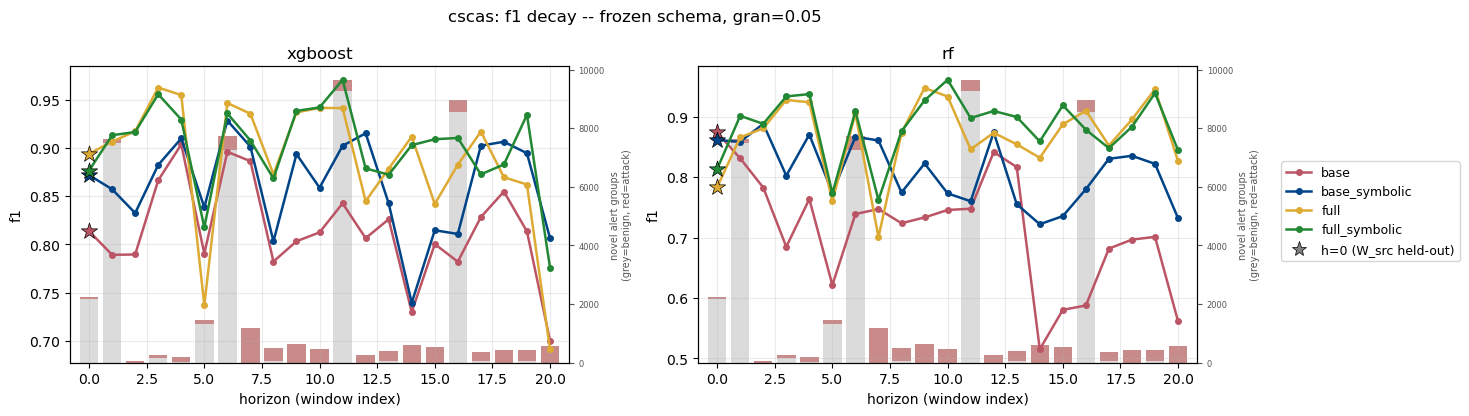

In [158]:
def _series_for(feature_set: str, model: str, metric: str, gran: float = None):
    """(horizons, median, q25, q75) for one (feature_set, model) at `gran`
    (default: the global GRAN). For a single curve (baseline/cscas_full)
    q25==q75==median."""
    sub = fs_rows(per_horizon, feature_set, model, gran=gran)
    if sub.empty or metric not in sub:
        return None
    g = sub.groupby("horizon_window_index")[metric]
    return g.median().index.values, g.median().values, g.quantile(0.25).values, g.quantile(0.75).values


def plot_decay(metric: str = None, models=None, show_groups: str | None = "novel") -> None:
    """show_groups: "novel" (default, groups unseen in training), "total"
    (every group in the window), or None/False to turn the bar overlay off."""
    metric = metric or PRIMARY_METRIC
    models = models or MODELS
    ncols = min(2, len(models))
    nrows = -(-len(models) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 4.2 * nrows), squeeze=False)
    for ax, model in zip(axes.flat, models):
        if show_groups:
            _overlay_group_bars(ax, mode=show_groups)
        for fs in FEATURE_SETS:
            s = _series_for(fs, model, metric)
            if s is None:
                continue
            h, med, q25, q75 = s
            color = FEATURE_SET_COLOR[fs]
            ax.plot(h, med, "-o", ms=4, lw=1.8, color=color, label=fs_label(fs), zorder=3)
            if SYMBOLIC_AS_BAND and (q75 > q25).any():
                ax.fill_between(h, q25, q75, color=color, alpha=0.18, lw=0, zorder=1)
            ax.scatter(h[:1], med[:1], color=color, marker="*", s=150,
                       edgecolor="black", linewidth=0.5, zorder=5)
        ax.set_title(model)
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.25)
        ax.margins(x=0.02)
    for ax in axes.flat[len(models):]:
        ax.set_visible(False)
    star = Line2D([], [], color="grey", marker="*", ms=11, ls="None",
                  markeredgecolor="black", markeredgewidth=0.5)
    h0, l0 = axes.flat[0].get_legend_handles_labels()
    fig.legend(h0 + [star], l0 + ["h=0 (W_src held-out)"],
               loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
    fig.suptitle(f"{SCENARIO}: {metric} decay -- frozen schema, gran={GRAN:g}")
    fig.tight_layout()
    save_fig(fig, "sec1", "decay", metric, f"gran={GRAN:g}")


plot_decay()

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec1_allmetrics_rf_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec1_allmetrics_xgboost_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec1_allmetrics_rf_gran=0.1.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec1_allmetrics_xgboost_gran=0.1.png


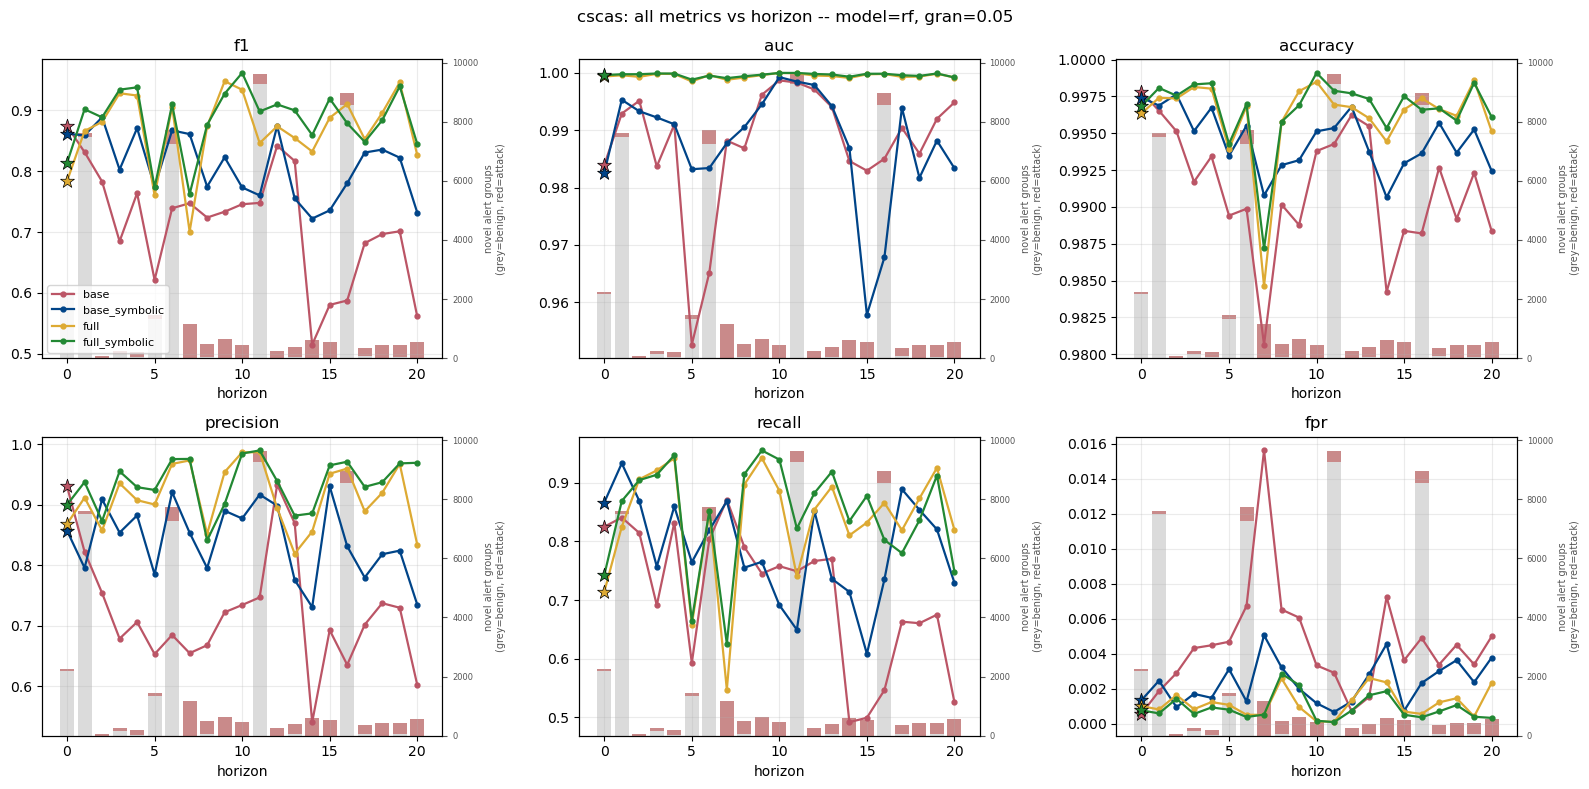

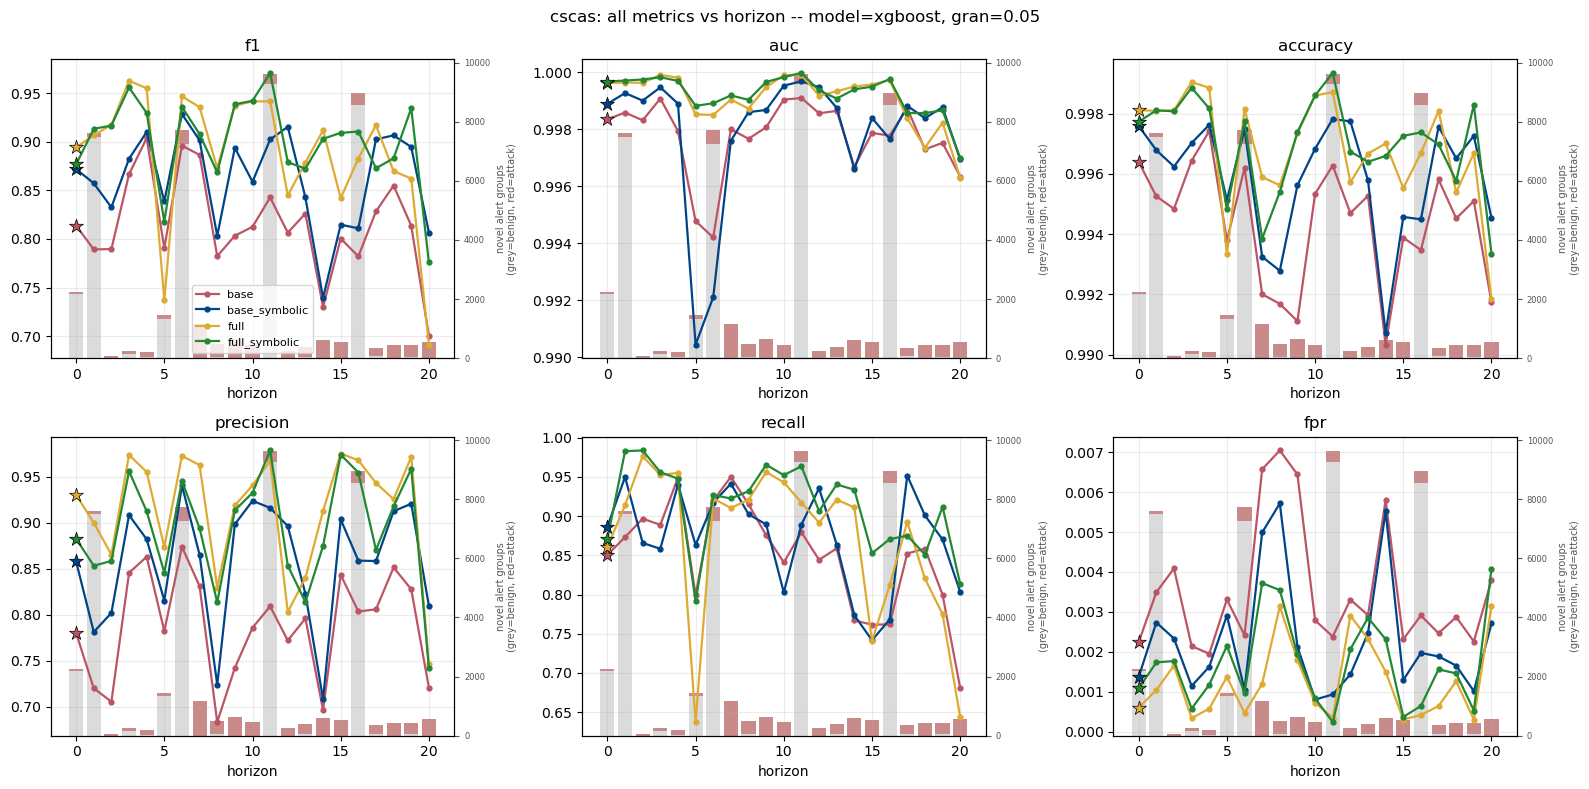

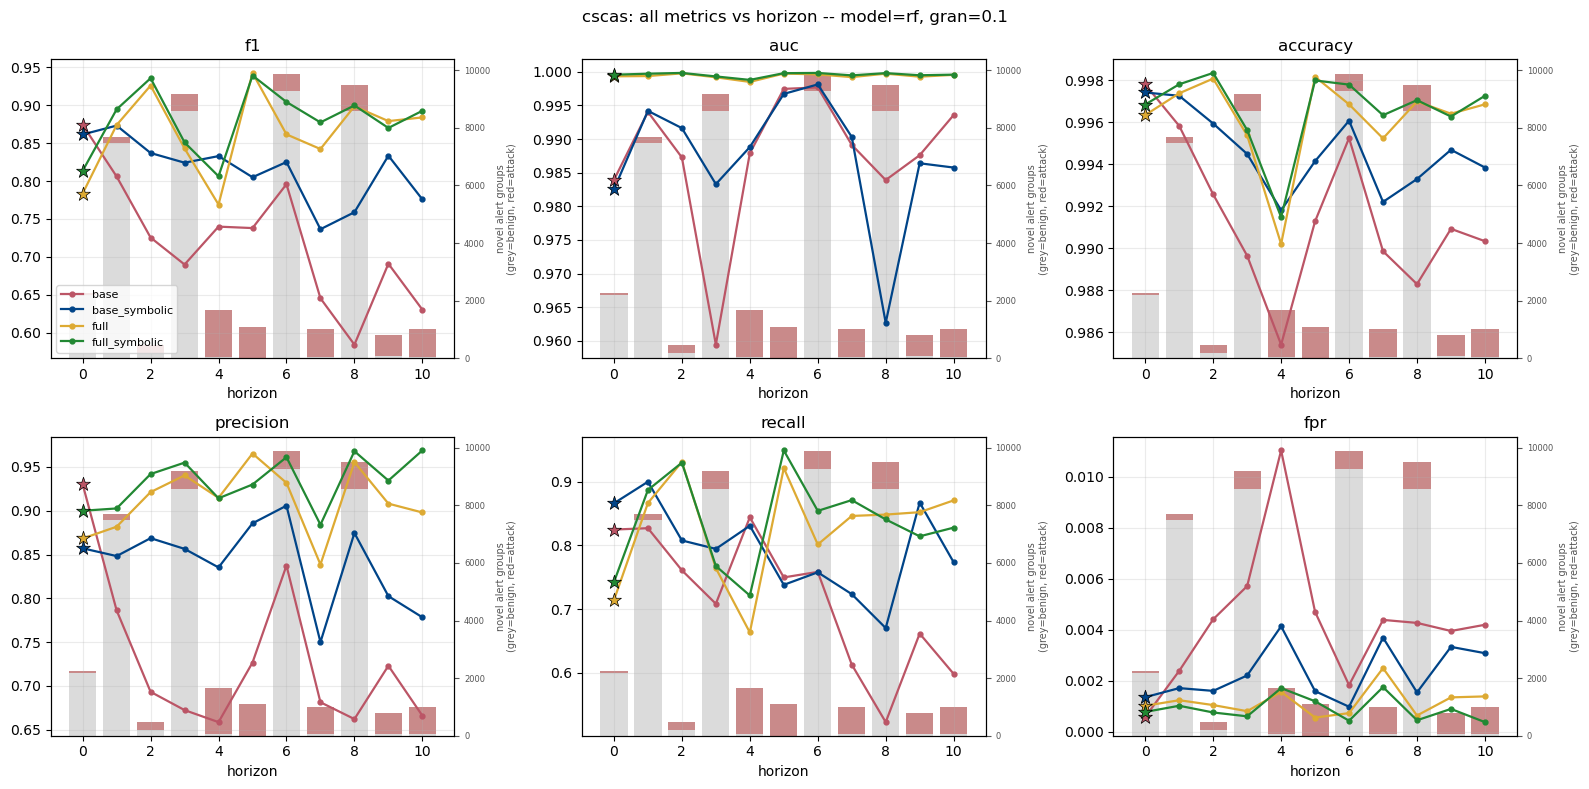

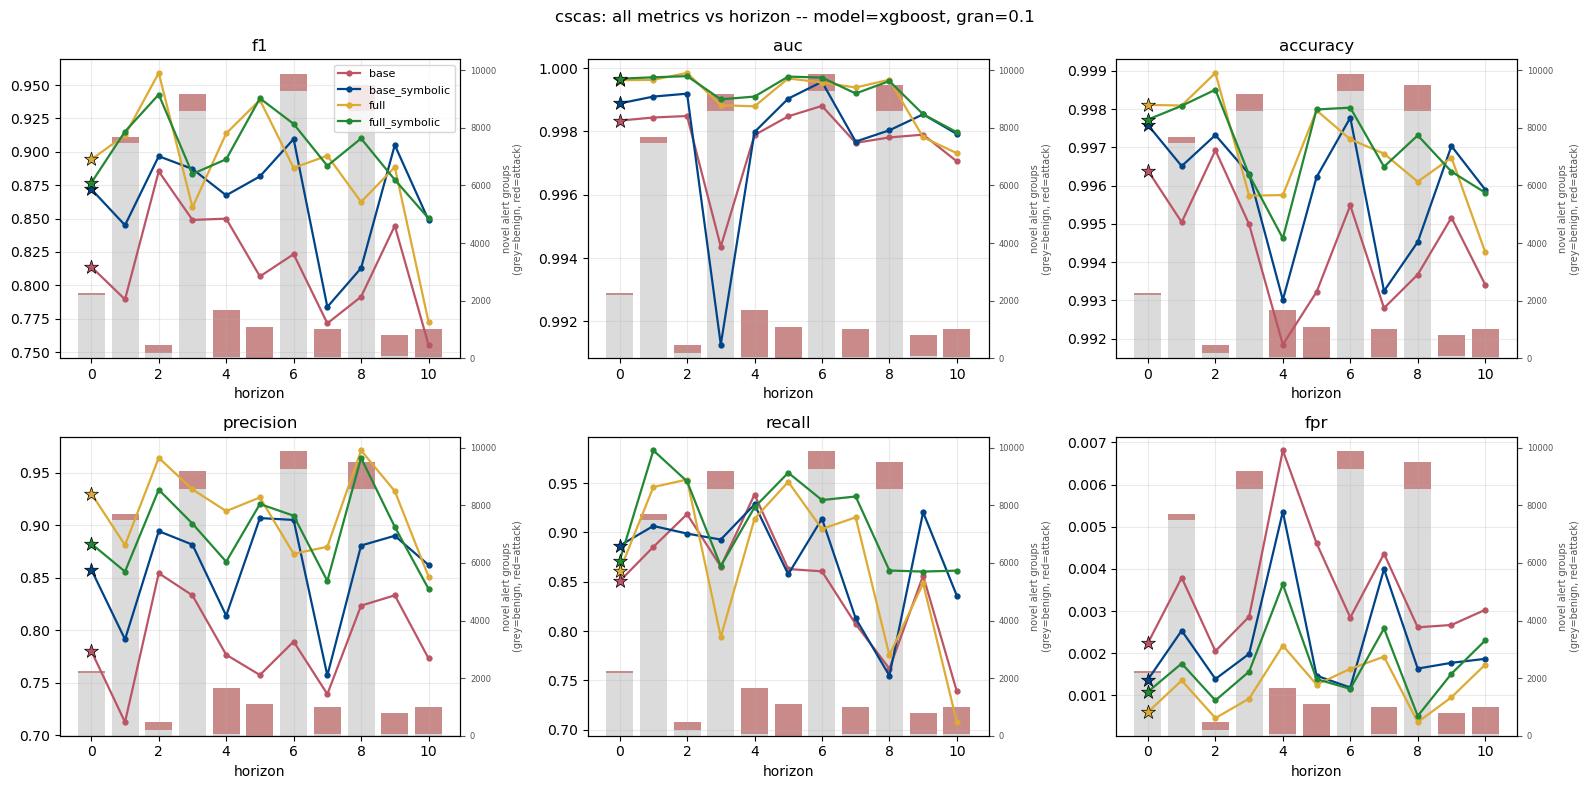

In [159]:
# Every metric, one model -- the full picture for a single detector.
def plot_all_metrics(model: str = None, gran: float = None,
                     show_groups: str | None = "novel") -> None:
    """gran: which granularity to plot (default: the global GRAN)."""
    model = model or MODELS[0]
    gran = GRAN if gran is None else gran
    metrics = [PRIMARY_METRIC] + [m for m in METRIC_COLS if m != PRIMARY_METRIC]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), squeeze=False)
    for ax, metric in zip(axes.flat, metrics):
        if show_groups:
            _overlay_group_bars(ax, mode=show_groups, gran=gran)
        for fs in FEATURE_SETS:
            s = _series_for(fs, model, metric, gran=gran)
            if s is None:
                continue
            h, med, q25, q75 = s
            ax.plot(h, med, "-o", ms=3.5, lw=1.6, color=FEATURE_SET_COLOR[fs], label=fs_label(fs))
            if SYMBOLIC_AS_BAND and (q75 > q25).any():
                ax.fill_between(h, q25, q75, color=FEATURE_SET_COLOR[fs], alpha=0.18, lw=0)
            ax.scatter(h[:1], med[:1], color=FEATURE_SET_COLOR[fs], marker="*", s=110,
                       edgecolor="black", linewidth=0.5, zorder=5)
        ax.set_title(metric)
        ax.set_xlabel("horizon")
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(f"{SCENARIO}: all metrics vs horizon -- model={model}, gran={gran:g}")
    fig.tight_layout()
    save_fig(fig, "sec1", "allmetrics", model, f"gran={gran:g}")


plot_all_metrics("rf")
plot_all_metrics("xgboost")
plot_all_metrics("rf", 0.1)
plot_all_metrics("xgboost", 0.1)

## 2. Decay summary

`decay_rate_{metric} = score(h=0) - score(h_max)` (positive = the frozen model
got worse); `fpr_drift = fpr(h_max) - fpr(h=0)` (positive = more false
positives). `h_max` is the last horizon reached.

In [160]:
sort_col = f"decay_rate_{PRIMARY_METRIC}"
ds = decay_summary.copy()
ds_view = ds.sort_values(sort_col, ascending=False) if sort_col in ds else ds
ds_view = ds_view.assign(feature_set=ds_view["feature_set"].map(fs_label))
ds_view

,feature_set,mining_setting,granularity,model,h_max,auc_at_h0,auc_at_h20,decay_rate_auc,f1_at_h0,f1_at_h20,decay_rate_f1,accuracy_at_h0,accuracy_at_h20,decay_rate_accuracy,precision_at_h0,precision_at_h20,decay_rate_precision,recall_at_h0,recall_at_h20,decay_rate_recall,fpr_at_h0,fpr_at_h20,fpr_drift,auc_at_h10,f1_at_h10,accuracy_at_h10,precision_at_h10,recall_at_h10,fpr_at_h10
0,base,NaN,0.05,rf,20,0.983923,0.994827,-0.010905,0.874317,0.561488,0.312829,0.997802,0.988360,0.009442,0.930233,0.602317,0.327916,0.824742,0.525843,0.298900,0.000579,0.004991,0.004412,NaN,NaN,NaN,NaN,NaN,NaN
2,base,NaN,0.10,rf,10,0.983923,NaN,-0.009652,0.874317,NaN,0.243988,0.997802,NaN,0.007469,0.930233,NaN,0.264209,0.824742,NaN,0.226476,0.000579,NaN,0.003612,0.993575,0.630329,0.990333,0.666023,0.598266,0.004191
5,full,NaN,0.05,xgboost,20,0.999619,0.996294,0.003325,0.894244,0.691194,0.203049,0.998113,0.991847,0.006265,0.930362,0.746094,0.184268,0.860825,0.643820,0.217005,0.000603,0.003150,0.002547,NaN,NaN,NaN,NaN,NaN,NaN
12,base_symbolic,gr3_md1_mda4_rounds2,0.05,rf,20,0.982525,0.983355,-0.000830,0.861538,0.732092,0.129446,0.997420,0.992436,0.004984,0.857143,0.734994,0.122149,0.865979,0.729213,0.136766,0.001350,0.003780,0.002429,NaN,NaN,NaN,NaN,NaN,NaN
7,full,NaN,0.10,xgboost,10,0.999619,NaN,0.002307,0.894244,NaN,0.121516,0.998113,NaN,0.003846,0.930362,NaN,0.079180,0.860825,NaN,0.153310,0.000603,NaN,0.001125,0.997312,0.772727,0.994267,0.851182,0.707514,0.001728
1,base,NaN,0.05,xgboost,20,0.998342,0.996335,0.002007,0.813810,0.700173,0.113637,0.996393,0.991736,0.004657,0.780142,0.720571,0.059571,0.850515,0.680899,0.169617,0.002242,0.003796,0.001553,NaN,NaN,NaN,NaN,NaN,NaN
9,full_symbolic,gr3_md1_mda4_rounds2,0.05,xgboost,20,0.999667,0.996986,0.002681,0.876783,0.775991,0.100792,0.997731,0.993344,0.004386,0.882507,0.741803,0.140703,0.871134,0.813483,0.057651,0.001085,0.004070,0.002985,NaN,NaN,NaN,NaN,NaN,NaN
14,base_symbolic,gr3_md1_mda4_rounds2,0.10,rf,10,0.982525,NaN,-0.003240,0.861538,NaN,0.085661,0.997420,NaN,0.003575,0.857143,NaN,0.078783,0.865979,NaN,0.092569,0.001350,NaN,0.001726,0.985765,0.775877,0.993845,0.778360,0.773410,0.003076
13,base_symbolic,gr3_md1_mda4_rounds2,0.05,xgboost,20,0.998885,0.996935,0.001950,0.871990,0.806543,0.065447,0.997587,0.994538,0.003049,0.857855,0.809740,0.048116,0.886598,0.803371,0.083227,0.001374,0.002714,0.001339,NaN,NaN,NaN,NaN,NaN,NaN
3,base,NaN,0.10,xgboost,10,0.998342,NaN,0.001286,0.813810,NaN,0.058268,0.996393,NaN,0.002978,0.780142,NaN,0.007002,0.850515,NaN,0.111787,0.002242,NaN,0.000785,0.997055,0.755542,0.993415,0.773140,0.738728,0.003028


In [161]:
# Aggregated: median decay across mining settings, per feature_set x model.
rate_cols = [c for c in decay_summary.columns if c.startswith("decay_rate_")] + ["fpr_drift"]
agg = (decay_summary.groupby(["feature_set", "model"])[rate_cols]
       .median().round(4)
       .reindex(pd.MultiIndex.from_product([FEATURE_SETS, MODELS], names=["feature_set", "model"]))
       .dropna(how="all"))
agg = agg.rename(index=FEATURE_SET_LABEL, level="feature_set")
print(f"median decay_rate / fpr_drift over mining settings (gran={GRAN:g})")
agg

median decay_rate / fpr_drift over mining settings (gran=0.05)


decay_rate_auc  decay_rate_f1  decay_rate_accuracy  decay_rate_precision  decay_rate_recall  fpr_drift
feature_set   model                                                                                                          
base          xgboost          0.0016         0.0860               0.0038                0.0333             0.1407     0.0012
              rf              -0.0103         0.2784               0.0085                0.2961             0.2627     0.0040
base_symbolic xgboost          0.0015         0.0443               0.0024                0.0219             0.0670     0.0009
              rf              -0.0020         0.1076               0.0043                0.1005             0.1147     0.0021
full          xgboost          0.0028         0.1623               0.0051                0.1317             0.1852     0.0018
              rf              -0.0000        -0.0717               0.0004                0.0023            -0.1309     0.0008
full_symbolic xgboost          0.0022         0.0637               0.0031                0.0919             0.0338     0.0021
              rf               0.0002        -0.0551               0.0002               -0.0692            -0.0458    -0.0004

## 3. Per-horizon feature-importance heatmaps

Signed mean importance per (feature, horizon): **red pushes the score toward
`attack`, blue toward `benign`**, intensity = strength. Rows are the
top-`HEATMAP_TOP_K` features by pooled mean |importance| across horizons;
columns are horizons.

Read a row left-to-right: a colour that fades or flips is a feature whose
influence on the model's output is drifting as the target window moves away
from W_src.

**Comparability.** These are model-*output* attributions, not accuracy. Raw
magnitudes are **not** comparable across model families (LinearExplainer vs
TreeExplainer vs LIME's local surrogate, plus the Platt squash for the
one-class models). Compare a row to itself over time, and compare *drift*
across models in §4 -- not the absolute colours between panels. This run has
SHAP only for `logreg`/`xgboost`; `iforest`/`ocsvm` show LIME.

In [162]:
def _imp_pivot(feature_set, model, method, mining_setting=None):
    """feature x horizon signed-importance table for one config, or None."""
    if not HAS_EXPLANATIONS:
        return None
    e = explanations
    m = (e.feature_set.eq(feature_set) & e.model.eq(model) & e.method.eq(method)
         & e.granularity.eq(GRAN))
    if feature_set in ("symbolic", "cscas_full_symbolic"):
        m &= e.mining_setting.eq(mining_setting or MS_ONE)
    sub = e[m]
    if sub.empty:
        return None
    return sub.pivot_table(index="feature", columns="horizon_window_index",
                           values="importance", aggfunc="mean")


def _drift_range(pivot: pd.DataFrame) -> pd.Series:
    """Signed-importance range (max - min across horizons) per feature --
    how far that feature's influence has moved, including a sign flip.
    Complements the pooled-mean-|importance| ranking below: that answers
    "which features matter most overall", this answers "which features'
    importance has drifted the most" -- not the same features in general."""
    return (pivot.max(axis=1) - pivot.min(axis=1)).fillna(0)


def _draw_heatmap(ax, pivot, title, k, rank_by="importance"):
    score = (_drift_range(pivot) if rank_by == "drift"
             else pivot.abs().fillna(0).mean(axis=1))
    order = score.sort_values(ascending=False).head(k).index
    pivot = pivot.loc[order]
    vmax = float(np.nanmax(np.abs(pivot.values))) or 1e-9
    im = ax.imshow(np.ma.masked_invalid(pivot.values), aspect="auto",
                   cmap=plt.get_cmap("RdBu_r"),
                   norm=mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"h{c}" for c in pivot.columns], fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(title, fontsize=9)
    return im


def heatmap_grid(feature_set: str, method: str = "lime", mining_setting=None, k=None, rank_by="importance") -> None:
    """One heatmap per model for a feature set + method."""
    k = k or HEATMAP_TOP_K
    models = [m for m in MODELS if _imp_pivot(feature_set, m, method, mining_setting) is not None]
    if not models:
        print(f"no {method.upper()} importances for feature_set={fs_label(feature_set)}")
        return
    fig, axes = plt.subplots(1, len(models),
                             figsize=(max(4.0, 0.5 * len(HORIZONS) + 2.6) * len(models), 0.32 * k + 1.6),
                             squeeze=False)
    for ax, model in zip(axes[0], models):
        im = _draw_heatmap(ax, _imp_pivot(feature_set, model, method, mining_setting), model, k, rank_by)
        ax.set_xlabel("horizon")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ms = (f"  [{ms_short(mining_setting or MS_ONE)}]"
          if feature_set in ("symbolic", "cscas_full_symbolic") else "")
    rb = "  [ranked by drift]" if rank_by == "drift" else ""
    fig.suptitle(f"{SCENARIO}: {method.upper()} signed importance drift -- "
                 f"{fs_label(feature_set)}{ms}{rb}  (red -> attack)")
    fig.tight_layout()
    ms_slug = (ms_short(mining_setting or MS_ONE)
              if feature_set in ("symbolic", "cscas_full_symbolic") else None)
    save_fig(fig, "sec3", "heatmap", fs_label(feature_set), method, rank_by,
             ms_slug, f"gran={GRAN:g}")

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_base_symbolic_lime_importance_md1_mda4_rounds2_gran=0.05.png


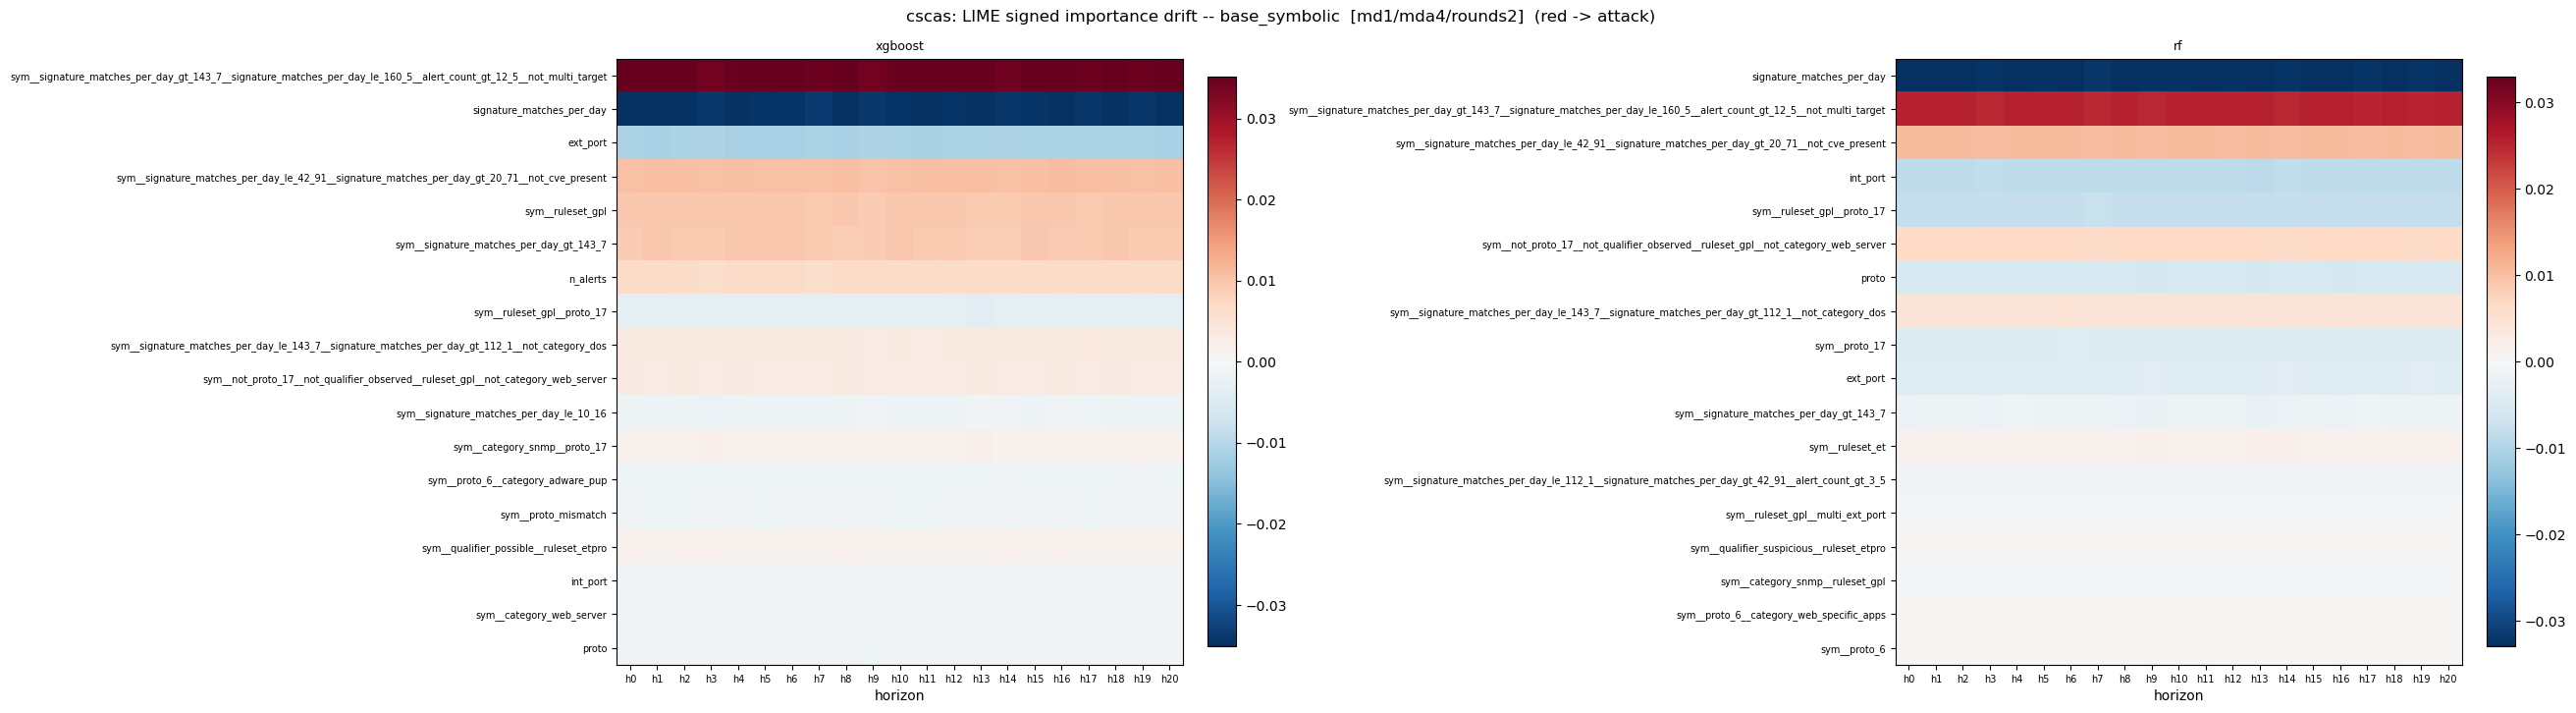

In [163]:
heatmap_grid("symbolic", "lime")

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_base_symbolic_shap_importance_md1_mda4_rounds2_gran=0.05.png


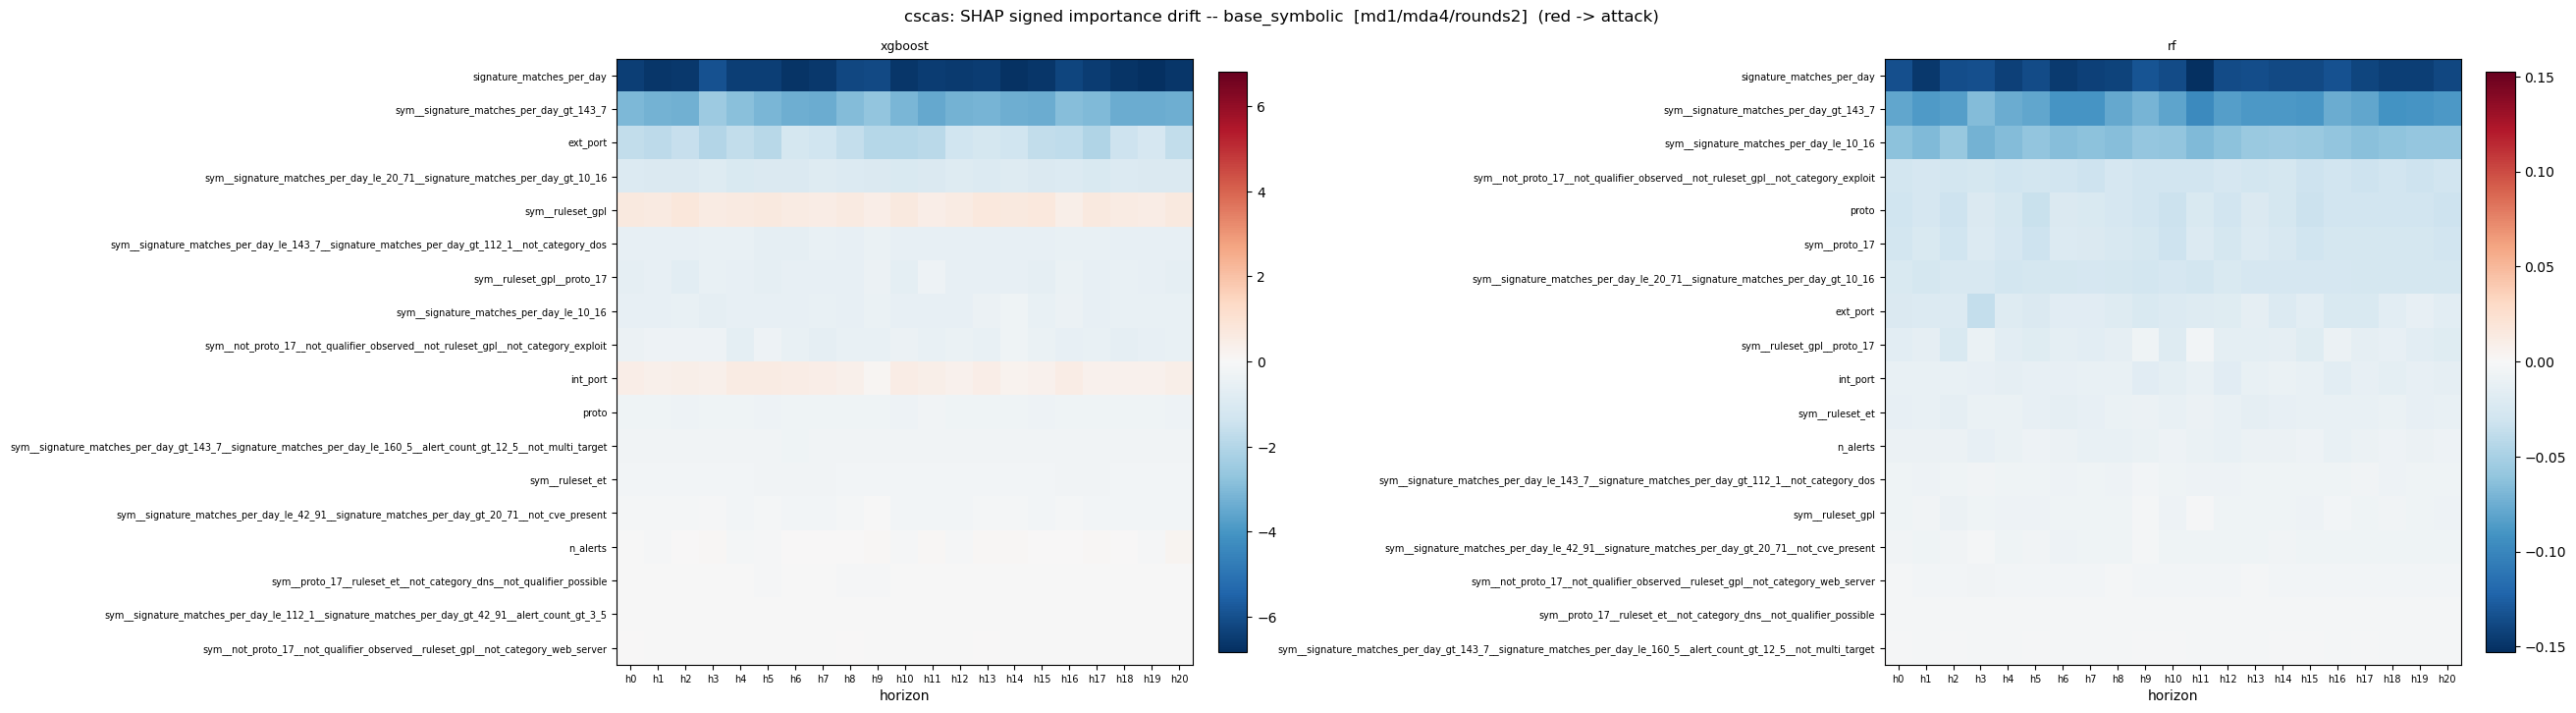

In [164]:
heatmap_grid("symbolic", "shap")   # logreg / xgboost only

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_full_lime_importance_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_full_symbolic_lime_importance_md1_mda4_rounds2_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_base_lime_importance_gran=0.05.png


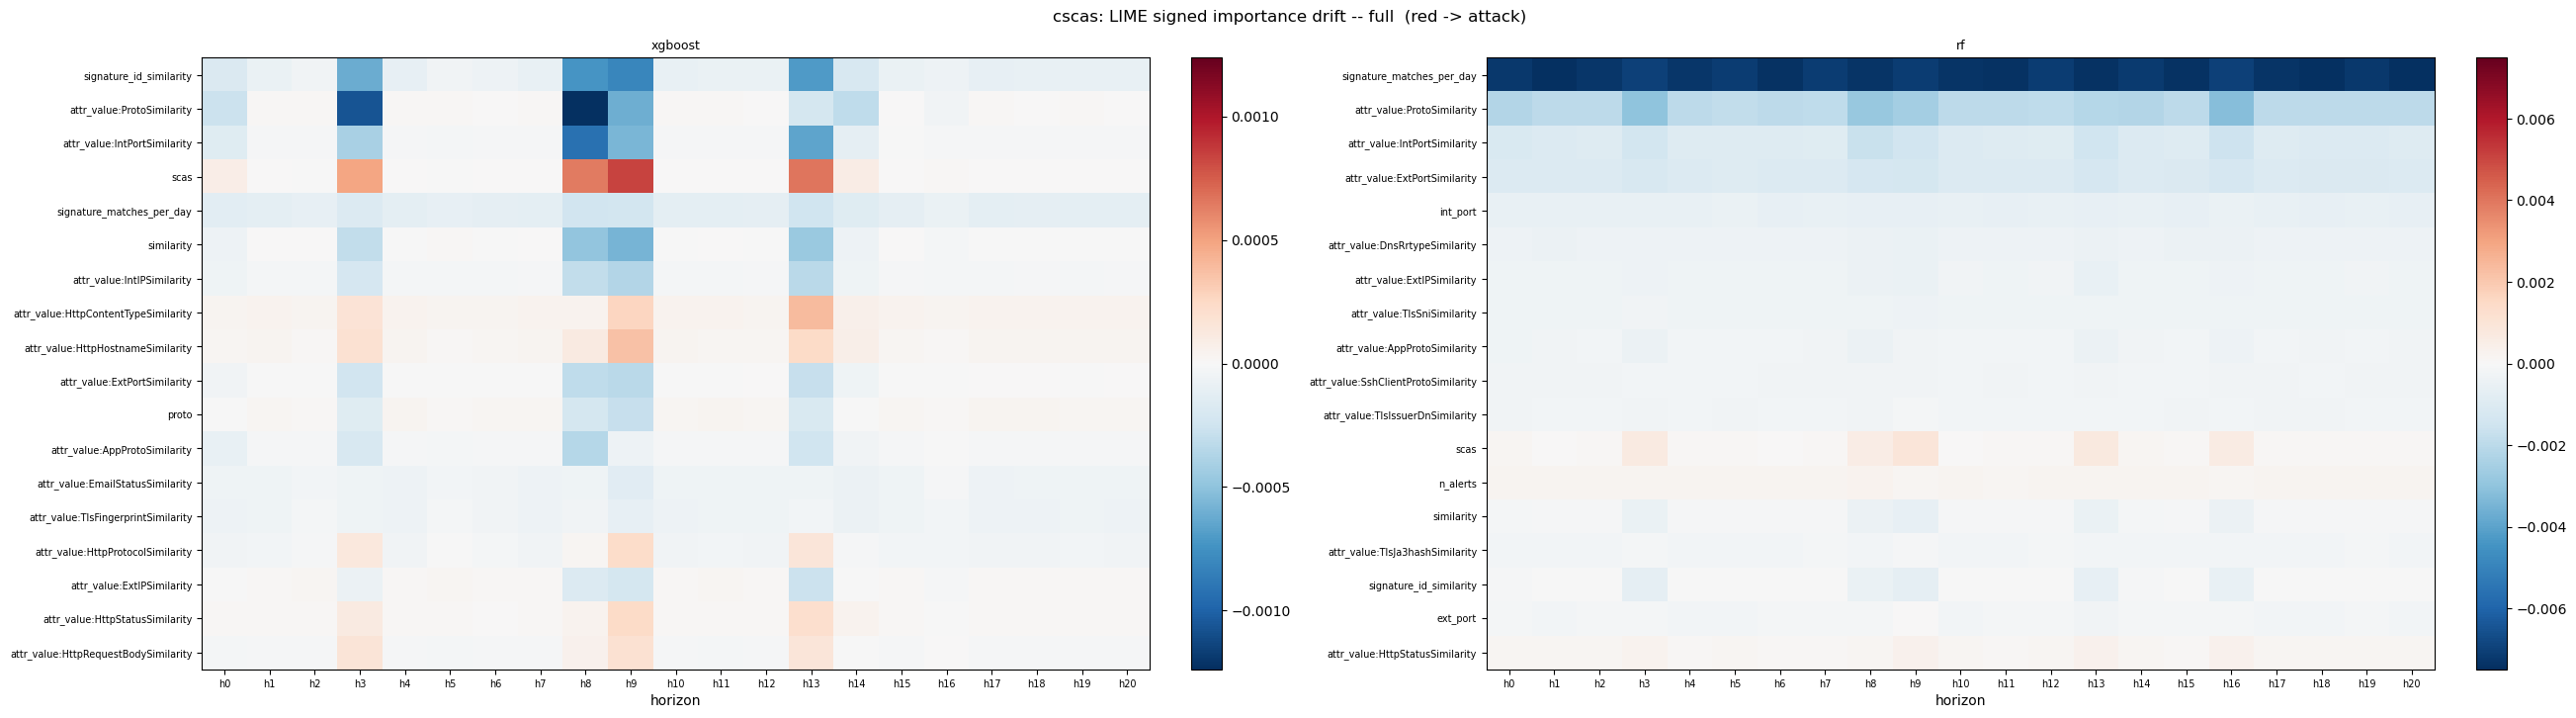

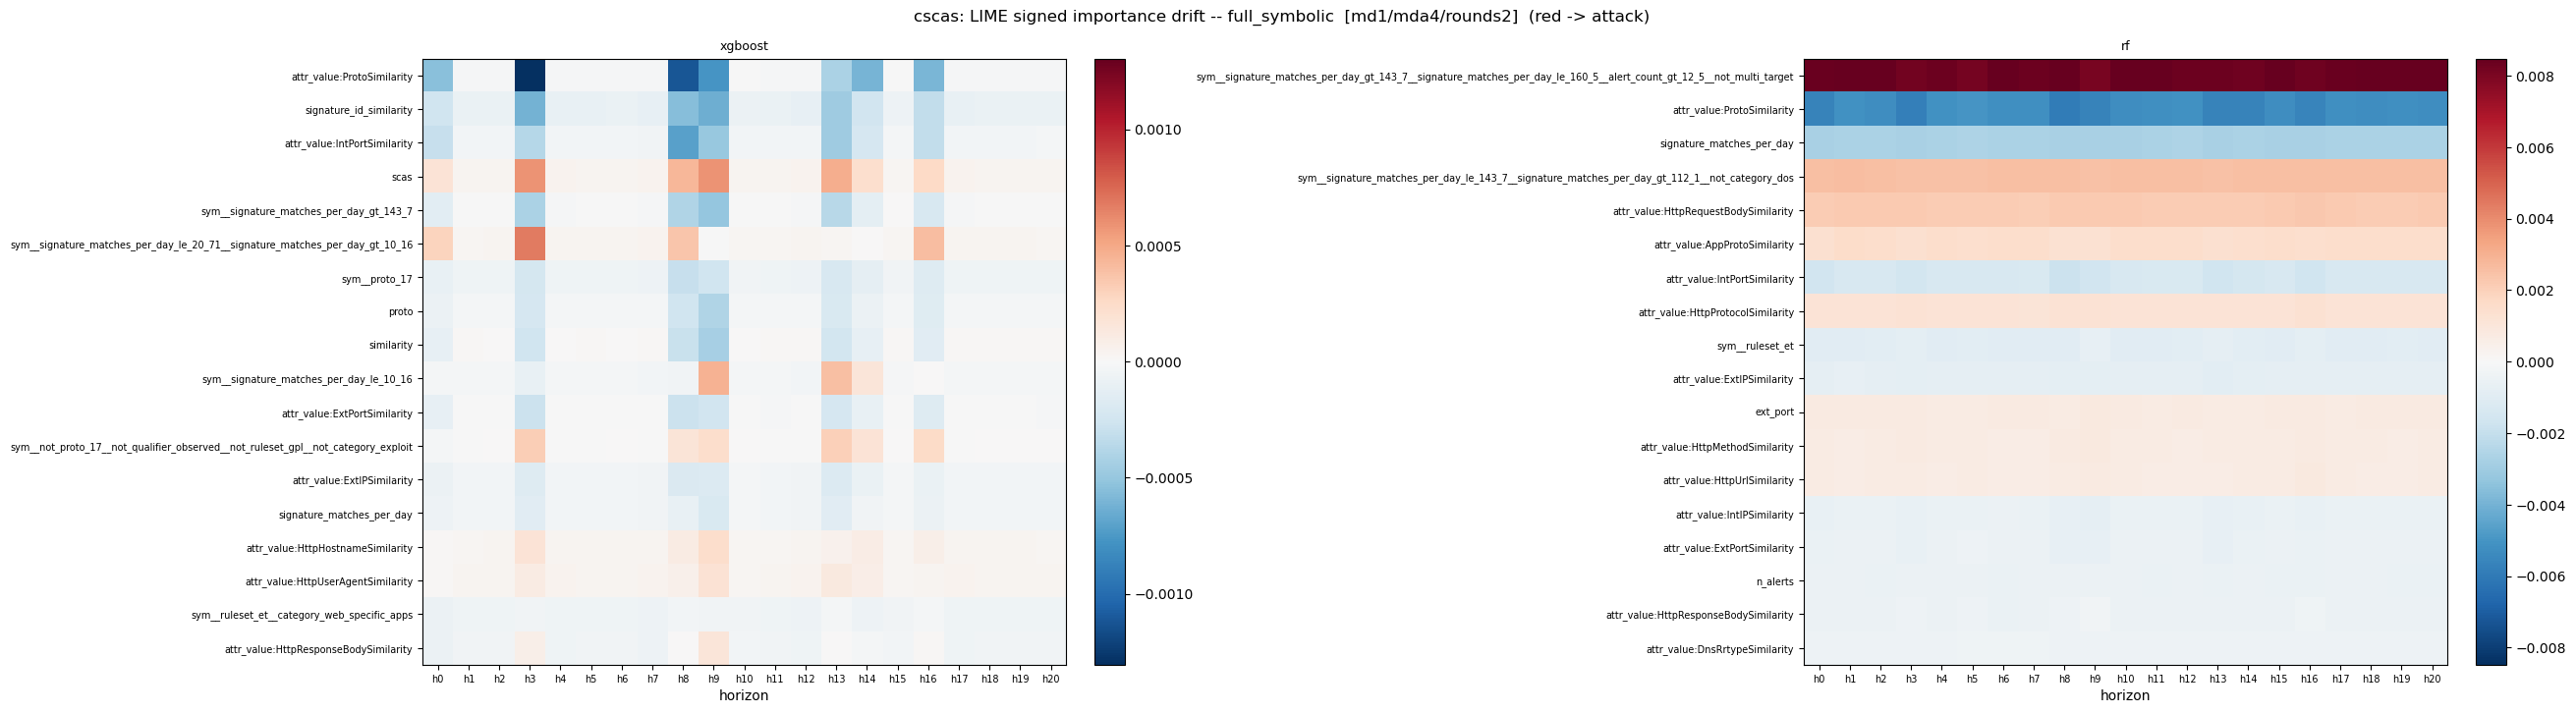

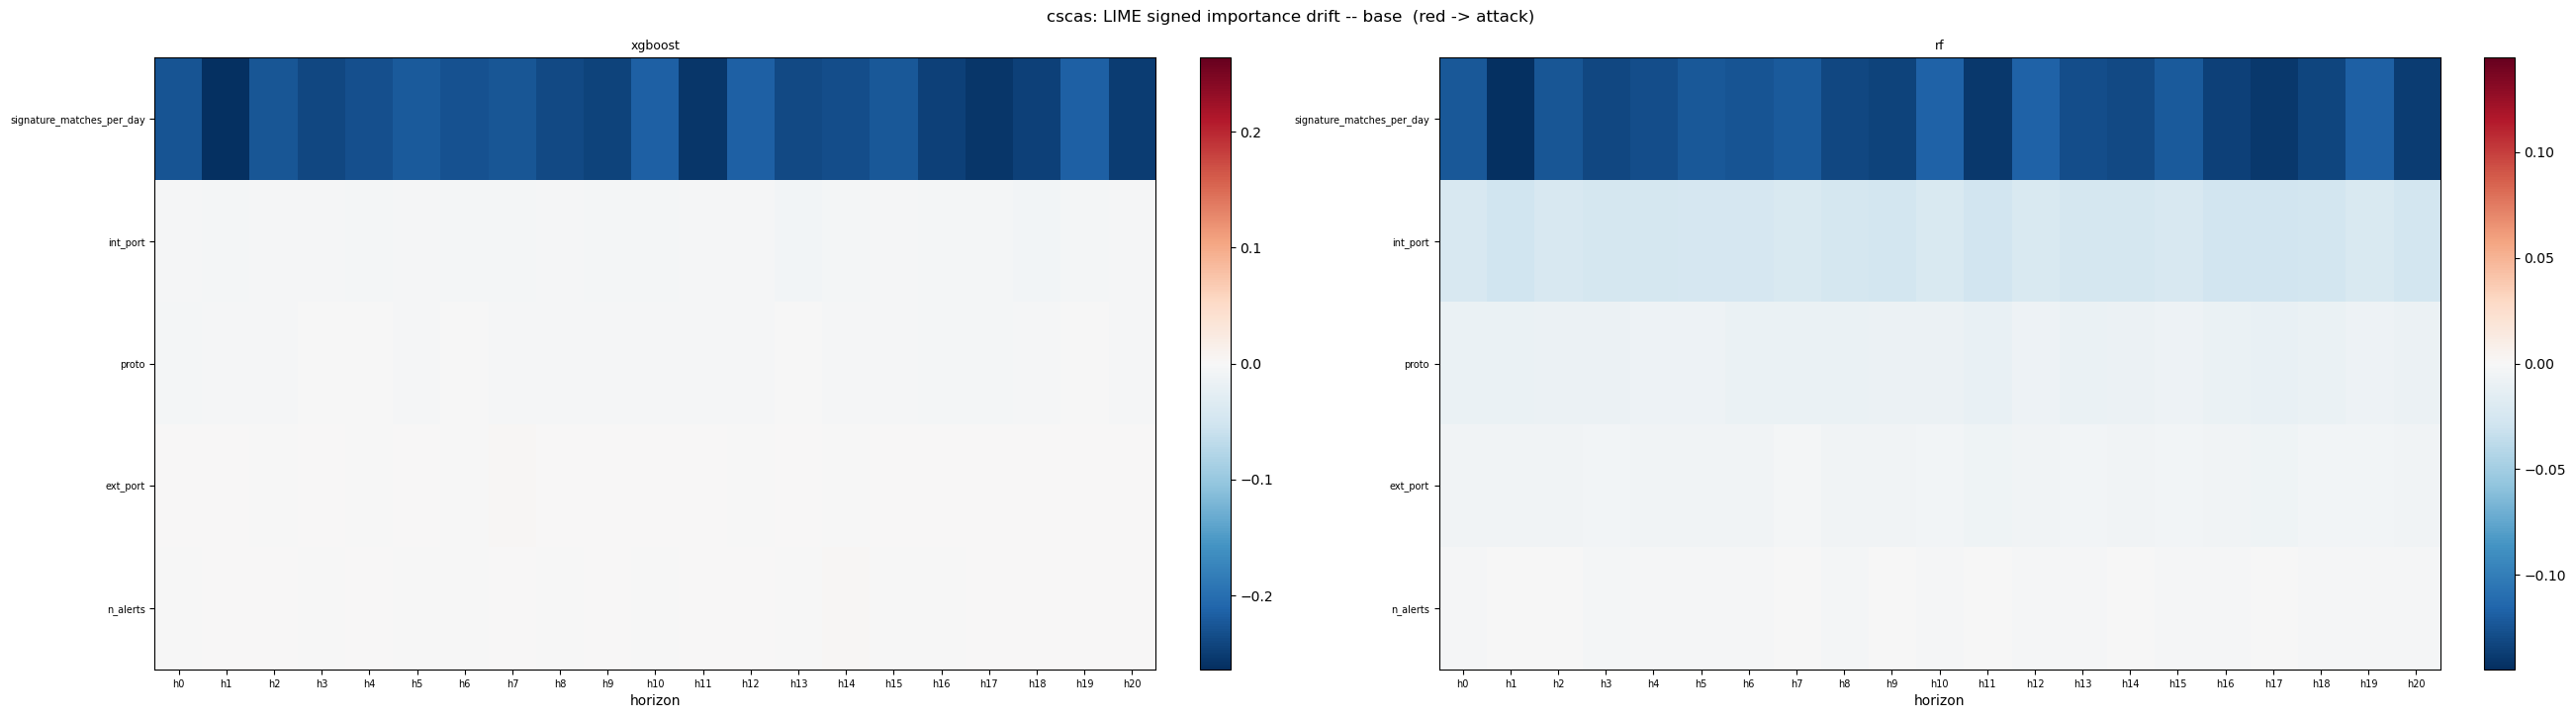

In [165]:
heatmap_grid("cscas_full", "lime")
heatmap_grid("cscas_full_symbolic", "lime")
heatmap_grid("baseline", "lime")


### Which individual features drift the most?

The heatmaps above rank rows by pooled mean |importance| -- the
consistently *influential* features, which aren't necessarily the ones
whose influence is *moving*. `top_drifting_features` ranks by signed range
(`max - min` across horizons) instead: the direct answer to "which
features' importance drifts the most over time", plus whether the sign
flipped between the first and last horizon shown. `heatmap_grid(...,
rank_by="drift")` draws the same heatmap with rows ranked this way instead.


In [166]:
def top_drifting_features(feature_set: str, method: str = "lime", model: str = None,
                          mining_setting=None, k: int = 15) -> pd.DataFrame:
    model = model or MODELS[0]
    pivot = _imp_pivot(feature_set, model, method, mining_setting)
    if pivot is None:
        print(f"no {method.upper()} importances for {fs_label(feature_set)}/{model}")
        return pd.DataFrame()
    h0, hmax = pivot.columns.min(), pivot.columns.max()
    v0, vmax = pivot[h0].fillna(0), pivot[hmax].fillna(0)
    out = pd.DataFrame({
        "drift_range": _drift_range(pivot),
        f"importance_at_h{h0}": pivot[h0],
        f"importance_at_h{hmax}": pivot[hmax],
        "sign_flip_h0_to_hmax": np.sign(v0) != np.sign(vmax),
    }).sort_values("drift_range", ascending=False).head(k)
    return out.round(4)


top_drifting_features("symbolic", model=MODELS[0])

,drift_range,importance_at_h0,importance_at_h20,sign_flip_h0_to_hmax
feature,,,,
sym__signature_matches_per_day_gt_143_7__signature_matches_per_day_le_160_5__alert_count_gt_12_5__not_multi_target,0.0013,0.0350,0.0351,False
signature_matches_per_day,0.0012,-0.0347,-0.0348,False
sym__signature_matches_per_day_le_20_71__signature_matches_per_day_gt_10_16,0.0011,0.0015,0.0006,False
sym__signature_matches_per_day_le_10_16,0.0010,-0.0019,-0.0018,False
sym__signature_matches_per_day_gt_143_7,0.0009,0.0089,0.0093,False
sym__not_proto_17__not_qualifier_observed__not_ruleset_gpl__not_category_exploit,0.0007,0.0011,0.0010,False
n_alerts,0.0007,0.0067,0.0067,False
sym__signature_matches_per_day_le_42_91__signature_matches_per_day_gt_20_71__not_cve_present,0.0006,0.0104,0.0105,False
proto,0.0006,-0.0010,-0.0010,False


  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_heatmap_base_symbolic_lime_drift_md1_mda4_rounds2_gran=0.05.png


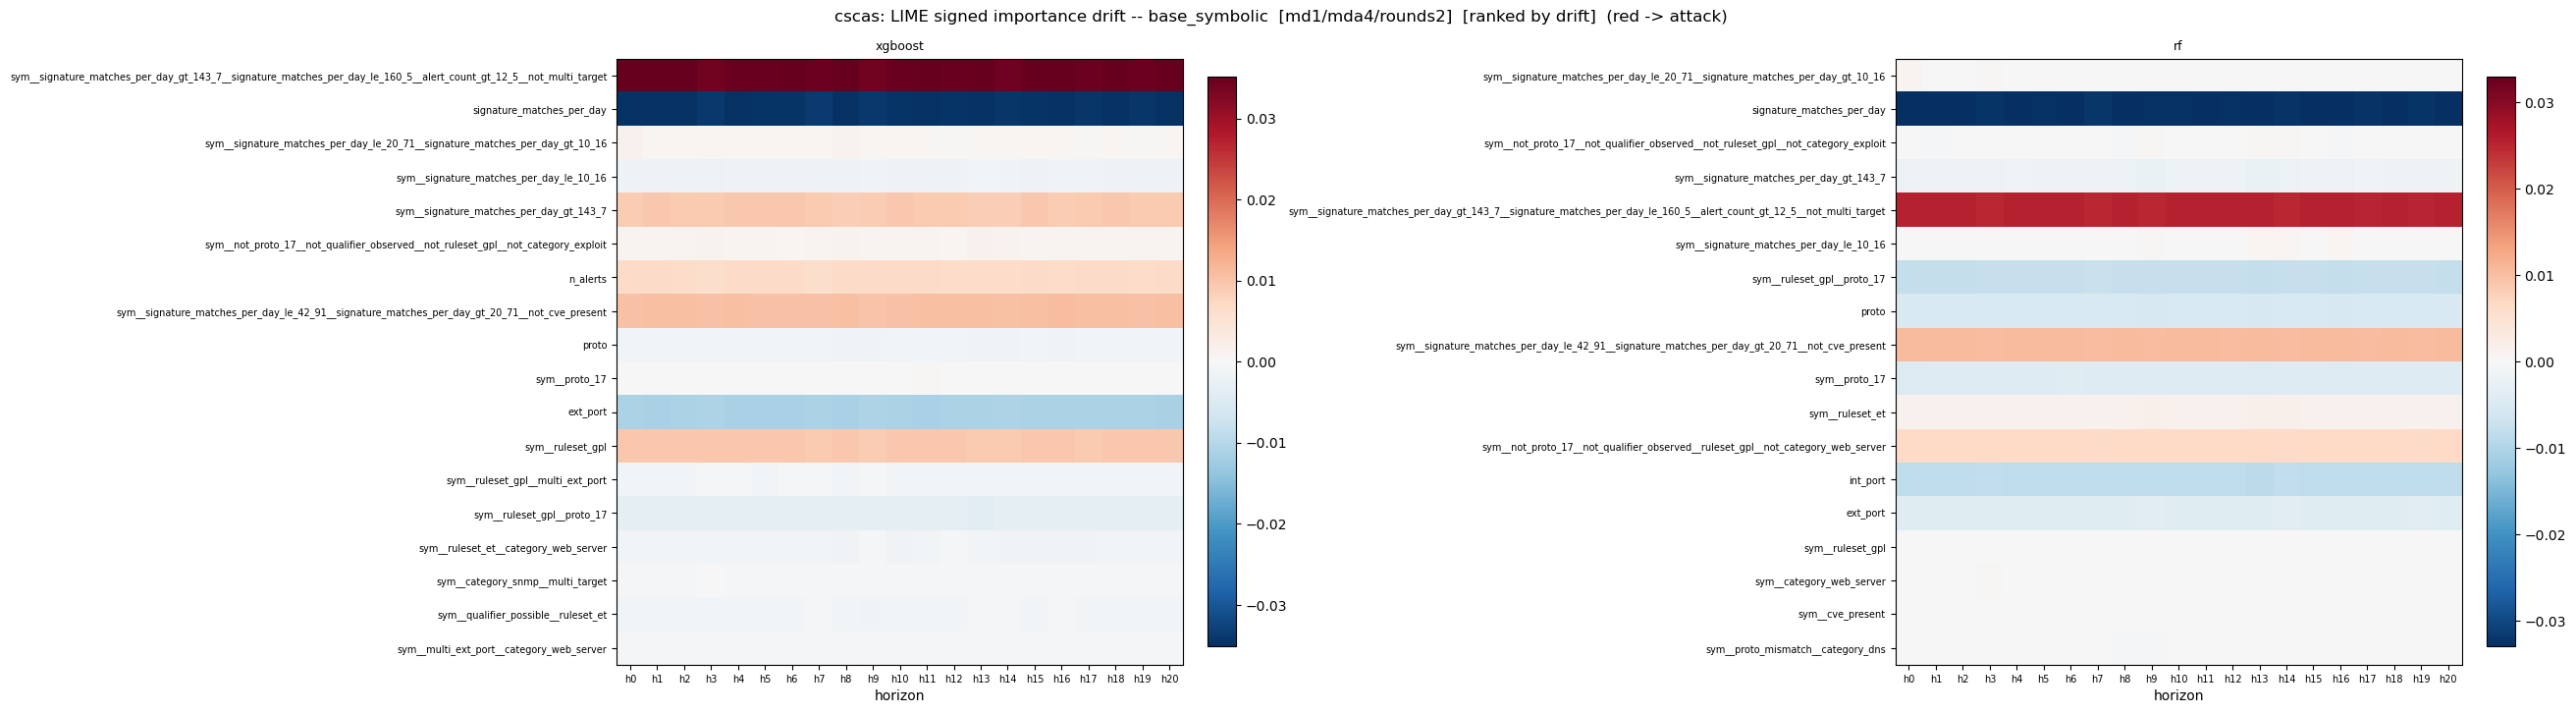

In [167]:
heatmap_grid("symbolic", "lime", rank_by="drift")


### Top-drifting feature trajectories

The heatmaps and the drift ranking above summarise each feature's movement
with a single number (pooled |importance|, or the h0-relative max drift).
This shows the trajectory *behind* that number, for the single most
h0-drifting feature per (schema, model): gradual drift vs. a single shock,
monotonic vs. oscillating -- shapes the summary numbers alone can't
distinguish. `rf` and `xgboost` usually have different top-1 features for
the same schema, so each line names its own feature rather than just the
model. Panel layout matches §4's spearman/agreement plots (one row, one
panel per schema); unlike those, the y-axis is **not** shared here --
raw signed importance spans ~2 orders of magnitude across schemas (`base`'s
LIME values are ~100x `full`'s), so a shared axis would flatten the
smaller-magnitude schemas to invisible lines.


  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec3_top_drift_trajectories_lime_top1_gran=0.05.png


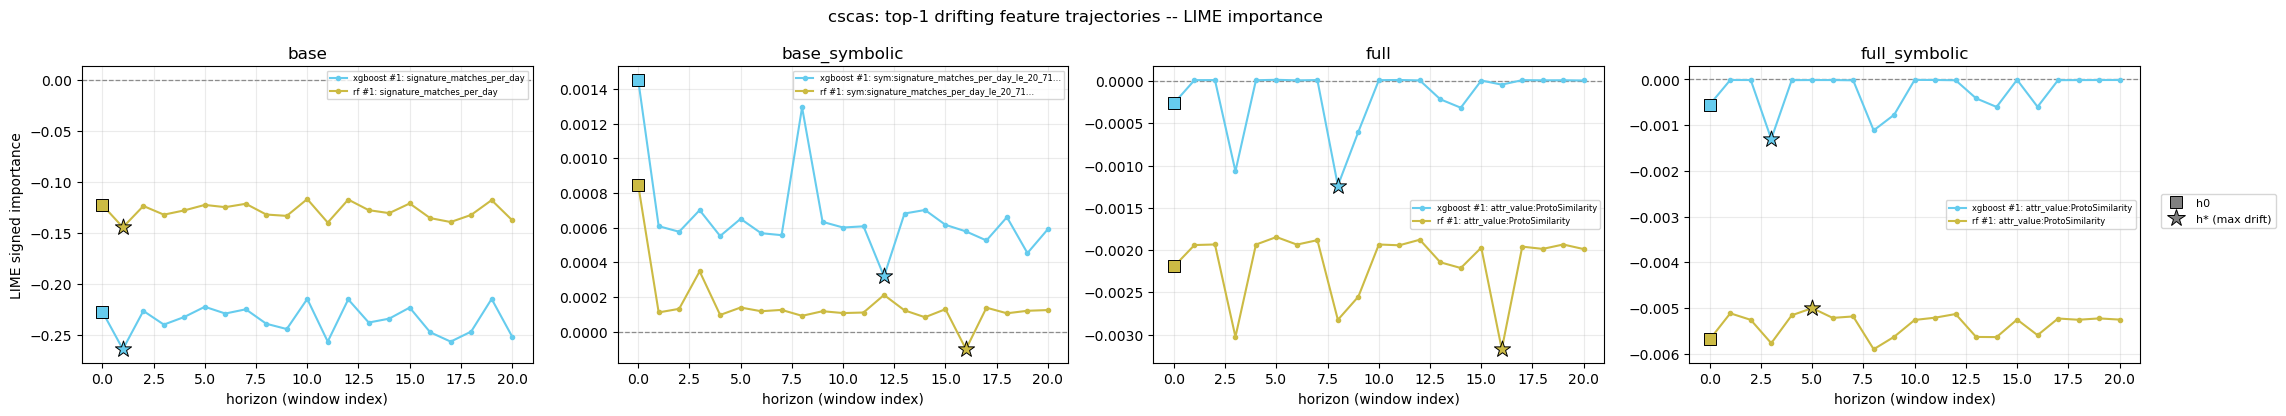

In [179]:
def _drift_from_h0(pivot: pd.DataFrame) -> pd.DataFrame:
    """max_h |I(h)-I(h0)| per feature, plus h* (the horizon of that max) and
    I(h*) -- the h0-relative drift ranking behind the top-drifting-feature
    trajectories below. Distinct from _drift_range's max-min-over-all-
    horizons range, which ignores where h0 itself sits."""
    h0 = pivot.columns.min()
    i0 = pivot[h0].fillna(0)
    dev = pivot.sub(i0, axis=0).abs().drop(columns=[h0])
    h_star = dev.idxmax(axis=1)
    i_hstar = pd.Series({f: pivot.loc[f, h_star[f]] for f in dev.index})
    return pd.DataFrame({"i_h0": i0, "h_star": h_star, "i_hstar": i_hstar,
                         "max_drift": dev.max(axis=1)}).sort_values("max_drift", ascending=False)


def _feat_short(feat: str) -> str:
    """Shorten a mined sym__ feature name to its first clause for legends --
    the raw predicate strings can run 80+ characters."""
    if not feat.startswith("sym__"):
        return feat
    clauses = feat[len("sym__"):].split("__")
    return f"sym:{clauses[0]}" if len(clauses) <= 1 else f"sym:{clauses[0]}…"


_RANK_LINESTYLE = ["-", "--", ":", "-."]  # rank 1, 2, 3, 4+ (cycles if top_n > 4)


def plot_top_drifting_trajectories(method: str = "lime", mining_setting=None,
                                   top_n: int = 3) -> None:
    """For each schema, the top-`top_n` most h0-drifting features' full
    signed-importance trajectories, per model -- colour = model, linestyle =
    rank within that model's own top-`top_n` (solid = rank 1, dashed = rank
    2, dotted = rank 3, ...). h0 (square) and h* (star -- the horizon of max
    drift, as in the top-drifting-features table) are marked on each line;
    a dashed line at 0 makes sign changes visible. top_n=1 reproduces the
    original single-line-per-model view."""
    fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(5.4 * len(FEATURE_SETS), 4.2),
                             squeeze=False, sharex=True, sharey=False)
    for ax, fs in zip(axes[0], FEATURE_SETS):
        for model in MODELS:
            pivot = _imp_pivot(fs, model, method, mining_setting)
            if pivot is None:
                continue
            ranked = _drift_from_h0(pivot)
            if ranked.empty:
                continue
            color = MODEL_COLOR[model]
            for rank, feat in enumerate(ranked.index[:top_n]):
                series = pivot.loc[feat].sort_index()
                h0 = series.index.min()
                h_star = int(ranked.loc[feat, "h_star"])
                ls = _RANK_LINESTYLE[rank % len(_RANK_LINESTYLE)]
                alpha = 1.0 if rank == 0 else 0.65
                ax.plot(series.index, series.values, ls, marker="o", ms=3, lw=1.5,
                        color=color, alpha=alpha,
                        label=f"{model} #{rank + 1}: {_feat_short(feat)}")
                ax.scatter([h0], [series[h0]], marker="s", s=80, color=color,
                          alpha=alpha, edgecolor="black", linewidth=0.7, zorder=6)
                ax.scatter([h_star], [series[h_star]], marker="*", s=150, color=color,
                          alpha=alpha, edgecolor="black", linewidth=0.7, zorder=6)
        ax.axhline(0, color="grey", lw=0.9, ls="--", zorder=1)
        ax.set_title(fs_label(fs))
        ax.set_xlabel("horizon (window index)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=6, loc="best")
    axes[0][0].set_ylabel(f"{method.upper()} signed importance")
    sq = Line2D([], [], color="grey", marker="s", ms=8, ls="None",
               markeredgecolor="black", markeredgewidth=0.7)
    st = Line2D([], [], color="grey", marker="*", ms=13, ls="None",
               markeredgecolor="black", markeredgewidth=0.7)
    fig.legend([sq, st], ["h0", "h* (max drift)"], loc="center left",
              bbox_to_anchor=(1.0, 0.5), fontsize=8)
    fig.suptitle(f"{SCENARIO}: top-{top_n} drifting feature trajectories -- {method.upper()} importance")
    fig.tight_layout()
    save_fig(fig, "sec3", "top_drift_trajectories", method, f"top{top_n}", f"gran={GRAN:g}")


plot_top_drifting_trajectories(top_n=1)

## 4. Importance stability vs. h=0 (cross-model comparable)

Raw importance magnitudes don't compare across model families, but **how much
the importance vector moves** does -- every measure below is normalised to
`[-1, 1]` or `[0, 1]` regardless of model, so `logreg` and `iforest` belong
on the same axis. All are computed against each config's own **frozen h=0
importance vector** (same frozen model, same frozen schema -> the vector only
moves because the target window drifts).

| measure | 1.0 means | drop means |
|---|---|---|
| `spearman`      | same feature ranking as h=0 | ranking is reshuffling |
| `cosine`        | same signed-importance direction | direction rotating |
| `jaccard_topk`  | same top-`STABILITY_TOP_K` features | the influential set is churning |
| `signflip_frac` | *(0.0 good)* fraction of features whose sign flipped vs h=0 | features changing which class they favour |

`iforest`/`ocsvm` use **LIME** (no SHAP this run); use `method="lime"` for a
like-for-like comparison across all four models.

In [169]:
from scipy.stats import spearmanr


def _stability_vs_h0(pivot: pd.DataFrame, k: int) -> pd.DataFrame:
    """pivot = feature x horizon signed importance. Compare every horizon to h0."""
    if pivot is None or 0 not in pivot.columns:
        return pd.DataFrame()
    v0 = pivot[0].fillna(0.0).values
    top0 = set(pd.Series(np.abs(v0), index=pivot.index).nlargest(k).index)
    rows = []
    for h in pivot.columns:
        vh = pivot[h].fillna(0.0).values
        denom = (np.linalg.norm(v0) * np.linalg.norm(vh)) or 1e-12
        toph = set(pd.Series(np.abs(vh), index=pivot.index).nlargest(k).index)
        both_nz = (v0 != 0) & (vh != 0)
        rows.append({
            "horizon_window_index": h,
            "spearman": spearmanr(v0, vh).correlation if np.ptp(v0) and np.ptp(vh) else np.nan,
            "cosine": float(v0 @ vh / denom),
            "jaccard_topk": len(top0 & toph) / len(top0 | toph),
            "signflip_frac": float(np.mean(np.sign(v0[both_nz]) != np.sign(vh[both_nz])))
                             if both_nz.any() else np.nan,
        })
    return pd.DataFrame(rows)


def stability_df(method: str = "lime") -> pd.DataFrame:
    """Long: one row per (feature_set, model, mining_setting, horizon) with the
    four stability measures vs that config's h0."""
    if not HAS_EXPLANATIONS:
        return pd.DataFrame()
    out = []
    for fs in FEATURE_SETS:
        settings = MINING_SETTINGS if fs in ("symbolic", "cscas_full_symbolic") else [None]
        for model in MODELS:
            for ms in settings:
                piv = _imp_pivot(fs, model, method, ms)
                st = _stability_vs_h0(piv, STABILITY_TOP_K)
                if st.empty:
                    continue
                st.insert(0, "feature_set", fs)
                st.insert(1, "model", model)
                st.insert(2, "mining_setting", ms)
                out.append(st)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


STAB_LIME = stability_df("lime")
STAB_LIME.head()

,feature_set,model,mining_setting,horizon_window_index,spearman,cosine,jaccard_topk,signflip_frac
0,baseline,xgboost,None,0,1.0,1.000000,1.0,0.0
1,baseline,xgboost,None,1,0.8,0.999888,1.0,0.2
2,baseline,xgboost,None,2,0.9,0.999935,1.0,0.4
3,baseline,xgboost,None,3,0.9,0.999747,1.0,0.0
4,baseline,xgboost,None,4,0.8,0.999780,1.0,0.4


  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec4_stability_LIME_spearman_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec4_stability_LIME_cosine_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec4_stability_LIME_jaccard_topk_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec4_stability_LIME_signflip_frac_gran=0.05.png


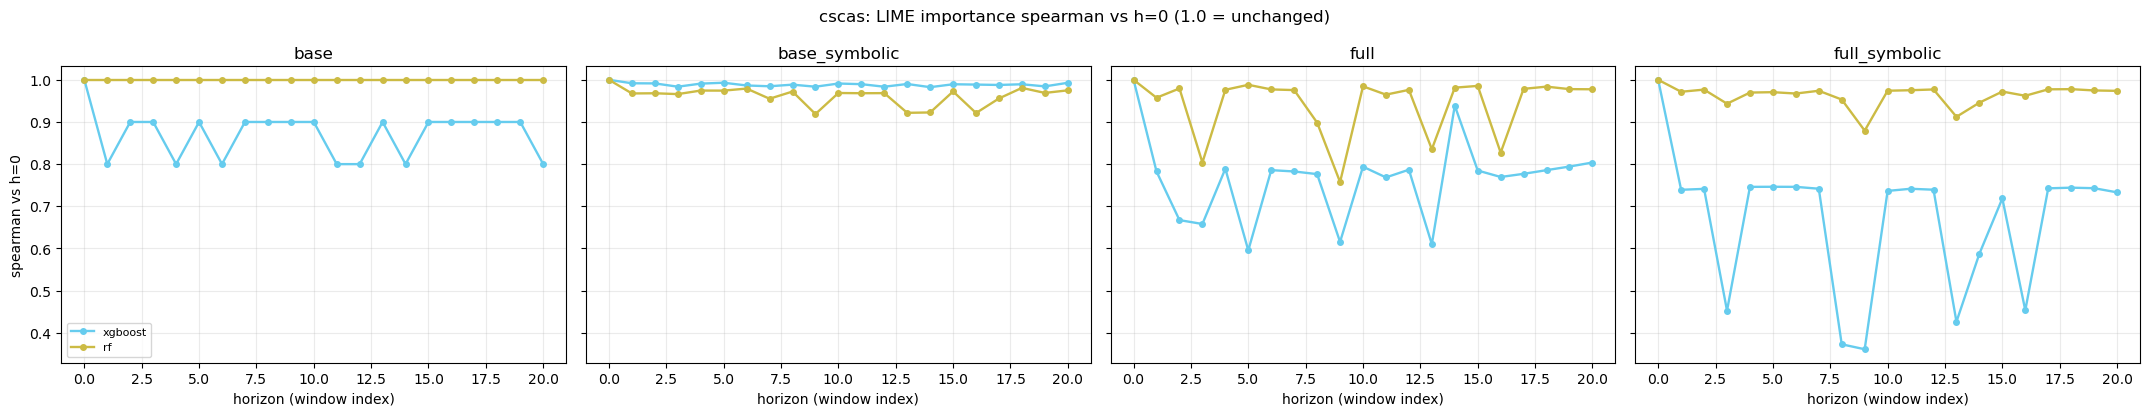

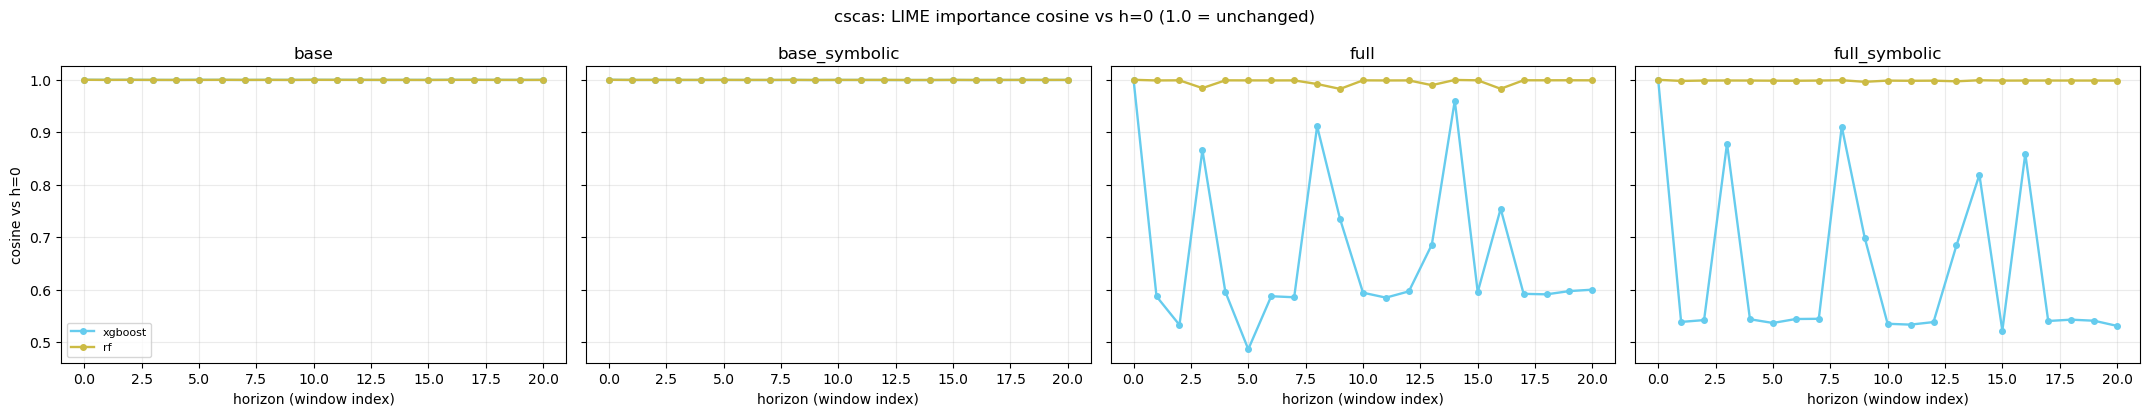

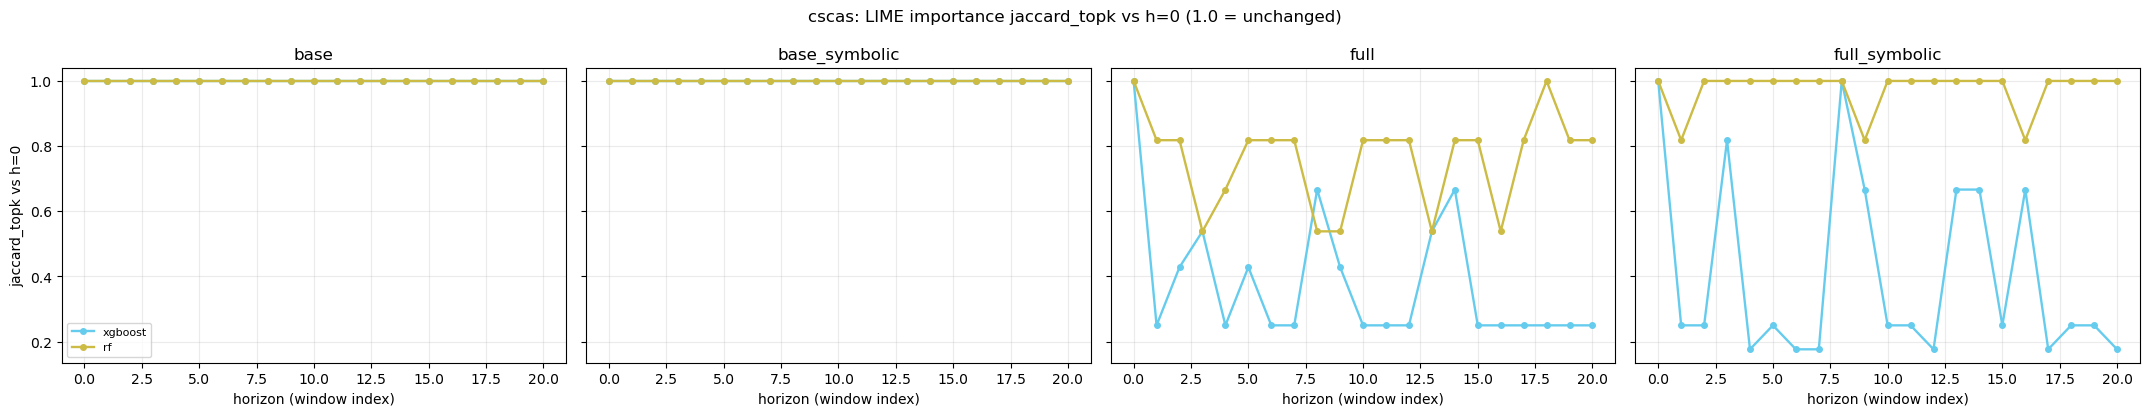

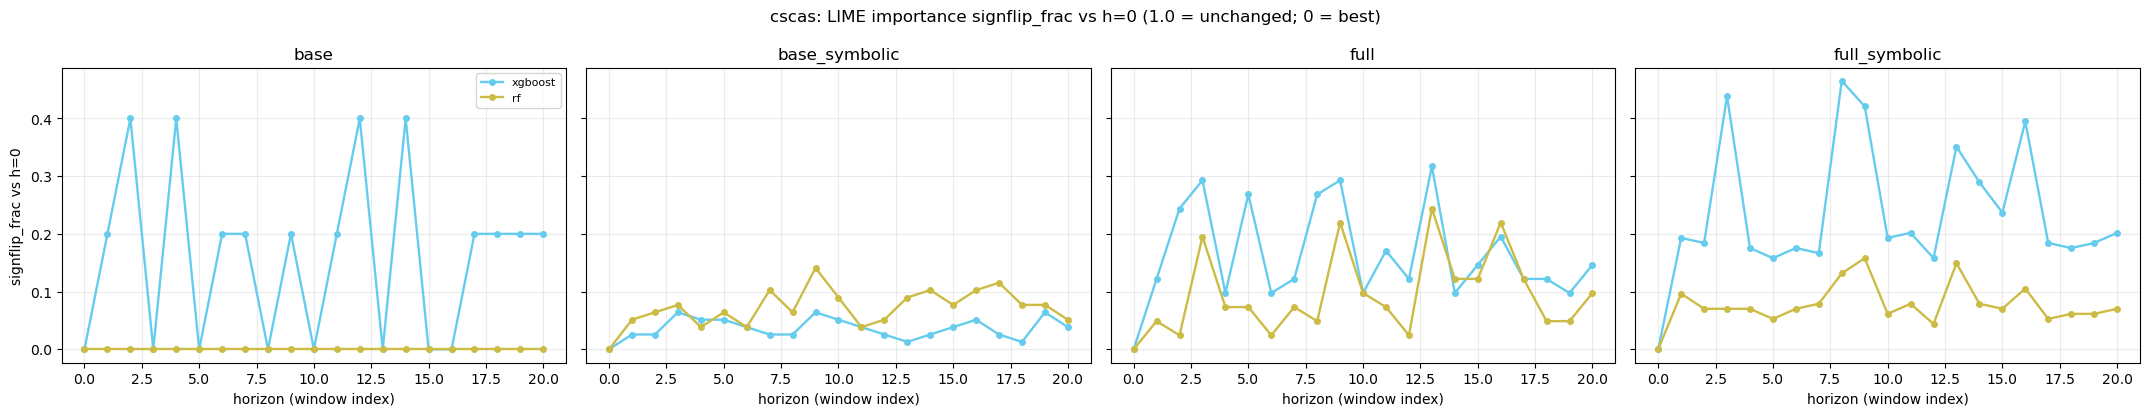

In [170]:
def plot_stability(measure: str = "spearman", method_df: pd.DataFrame = None,
                   method_name: str = "LIME") -> None:
    """One panel per feature set, one line per model (median over mining
    settings for symbolic, IQR band)."""
    sdf = STAB_LIME if method_df is None else method_df
    if sdf.empty:
        print("no stability data (no explanations)")
        return
    fss = [fs for fs in FEATURE_SETS if fs in set(sdf.feature_set)]
    fig, axes = plt.subplots(1, len(fss), figsize=(5.4 * len(fss), 4.2), squeeze=False, sharey=True)
    for ax, fs in zip(axes[0], fss):
        for model in MODELS:
            g = sdf[(sdf.feature_set == fs) & (sdf.model == model)]
            if g.empty:
                continue
            gg = g.groupby("horizon_window_index")[measure]
            h = gg.median().index.values
            ax.plot(h, gg.median().values, "-o", ms=4, lw=1.7,
                    color=MODEL_COLOR[model], label=model)
            if g.mining_setting.notna().any() and g.mining_setting.nunique() > 1:
                ax.fill_between(h, gg.quantile(.25).values, gg.quantile(.75).values,
                                color=MODEL_COLOR[model], alpha=0.15, lw=0)
        ax.set_title(fs_label(fs))
        ax.set_xlabel("horizon (window index)")
        ax.grid(alpha=0.25)
    axes[0][0].set_ylabel(f"{measure} vs h=0")
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"{SCENARIO}: {method_name} importance {measure} vs h=0 "
                 f"(1.0 = unchanged{'; 0 = best' if measure == 'signflip_frac' else ''})")
    fig.tight_layout()
    save_fig(fig, "sec4", "stability", method_name, measure, f"gran={GRAN:g}")


plot_stability("spearman")
plot_stability("cosine")
plot_stability("jaccard_topk")
plot_stability("signflip_frac")

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec4_shap_lime_agreement_gran=0.05.png


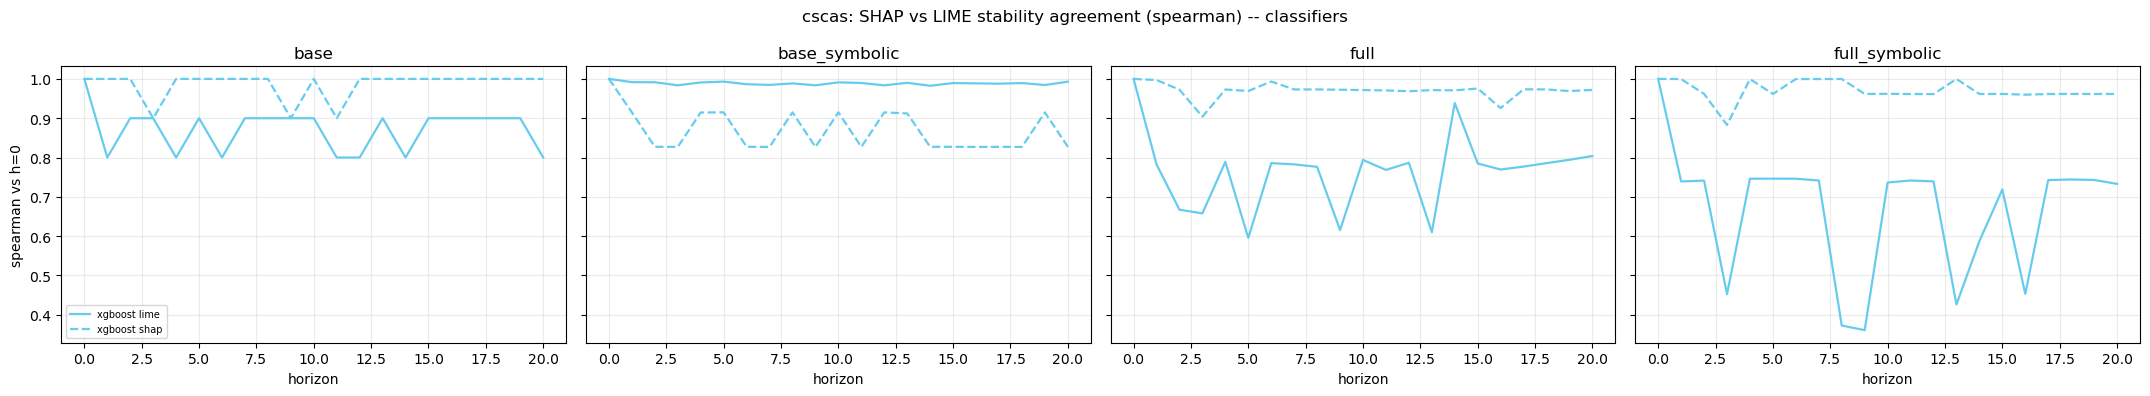

In [171]:
# Sanity: for the two classifiers, does SHAP tell the same stability story as LIME?
STAB_SHAP = stability_df("shap")
if not STAB_SHAP.empty:
    m = "spearman"
    both = (pd.concat([STAB_LIME.assign(expl="lime"), STAB_SHAP.assign(expl="shap")])
            .query("model in ['logreg', 'xgboost']"))
    fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(5.4 * len(FEATURE_SETS), 4), squeeze=False, sharey=True)
    for ax, fs in zip(axes[0], FEATURE_SETS):
        for model in ["logreg", "xgboost"]:
            for expl, ls in [("lime", "-"), ("shap", "--")]:
                g = both[(both.feature_set == fs) & (both.model == model) & (both.expl == expl)]
                if g.empty:
                    continue
                gg = g.groupby("horizon_window_index")[m].median()
                ax.plot(gg.index, gg.values, ls, color=MODEL_COLOR[model], lw=1.6,
                        label=f"{model} {expl}")
        ax.set_title(fs_label(fs)); ax.set_xlabel("horizon"); ax.grid(alpha=0.25)
    axes[0][0].set_ylabel(f"{m} vs h=0"); axes[0][0].legend(fontsize=7)
    fig.suptitle(f"{SCENARIO}: SHAP vs LIME stability agreement ({m}) -- classifiers")
    fig.tight_layout()
    save_fig(fig, "sec4", "shap_lime_agreement", f"gran={GRAN:g}")
else:
    print("no SHAP importances logged -- skipping SHAP/LIME agreement check")

## 5. Decay rate / acceleration vs. novel traffic

Discrete derivatives of a metric along the horizon:

- **velocity** `v(h) = m(h) - m(h-1)` -- per-window change (negative = decaying)
- **acceleration** `a(h) = v(h) - v(h-1)` -- is the decay speeding up?

Overlaid (right axis) with how much genuinely-unseen traffic each window
brings: `n_new_item_types` (raw_items token-sets not present in W_src's train
span) and `frac_novel_items_attack` (share of that window's *attacks* whose
type is new). Horizon `h` is a window index -- the windows differ in size and
composition, so these are per-window rates, not per-unit-time; second
differences on ~10 points are noisy, read them for direction not magnitude.

In [172]:
def decay_dynamics(metric: str = None) -> pd.DataFrame:
    """Per (feature_set, model, mining_setting): velocity + acceleration of
    `metric` along the horizon."""
    metric = metric or PRIMARY_METRIC
    keys = ["feature_set", "model", "mining_setting"]
    out = []
    for k, g in PH.groupby(keys, dropna=False):
        g = g.sort_values("horizon_window_index")
        v = g[metric].diff()
        out.append(g[["horizon_window_index"]].assign(
            **dict(zip(keys, k if isinstance(k, tuple) else (k,))),
            value=g[metric].values, velocity=v.values, acceleration=v.diff().values))
    return pd.concat(out, ignore_index=True)


DYN = decay_dynamics()
DYN.head()

,horizon_window_index,feature_set,model,mining_setting,value,velocity,acceleration
0,0,baseline,rf,NaN,0.874317,NaN,NaN
1,1,baseline,rf,NaN,0.831269,-0.043048,NaN
2,2,baseline,rf,NaN,0.782979,-0.048291,-0.005243
3,3,baseline,rf,NaN,0.684815,-0.098163,-0.049873
4,4,baseline,rf,NaN,0.763865,0.079050,0.177213


  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec5_rate_vs_novelty_velocity_f1_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec5_rate_vs_novelty_acceleration_f1_gran=0.05.png


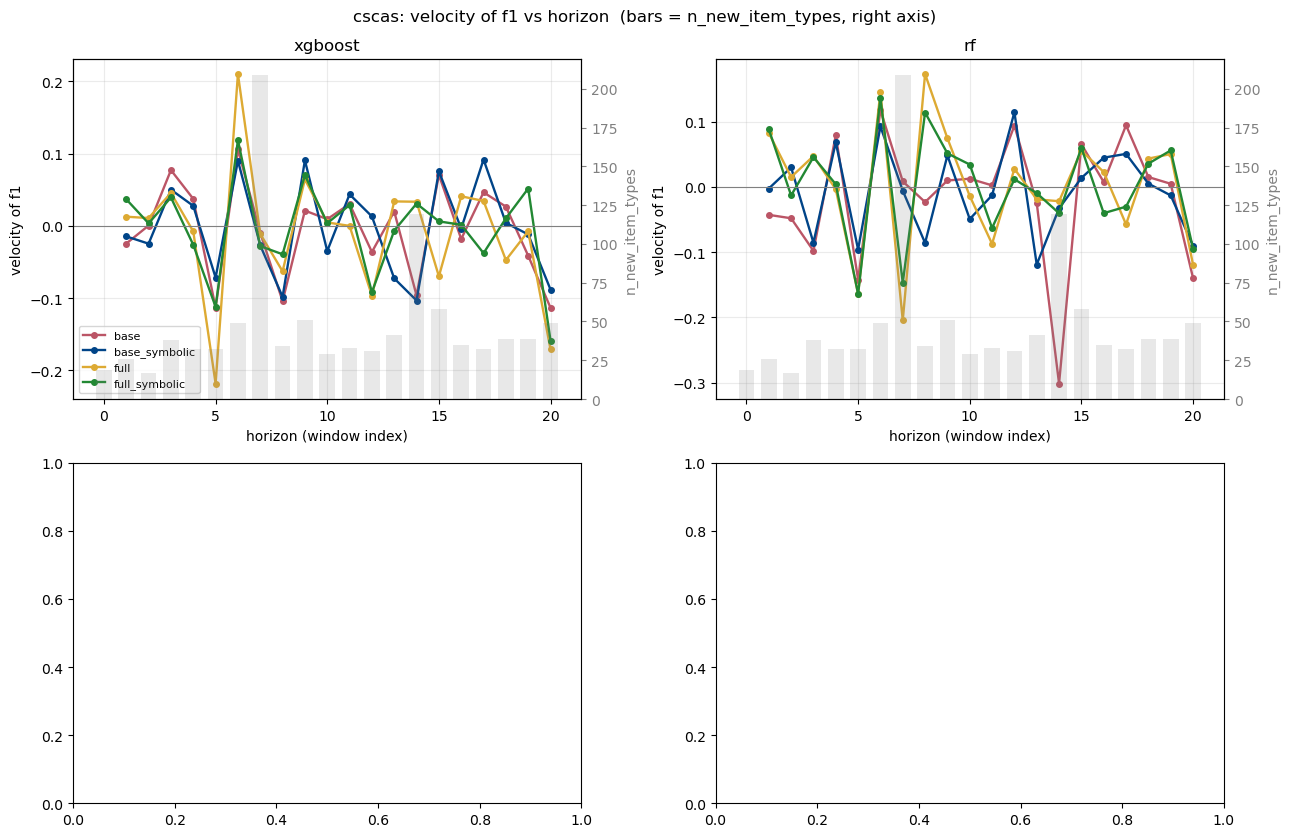

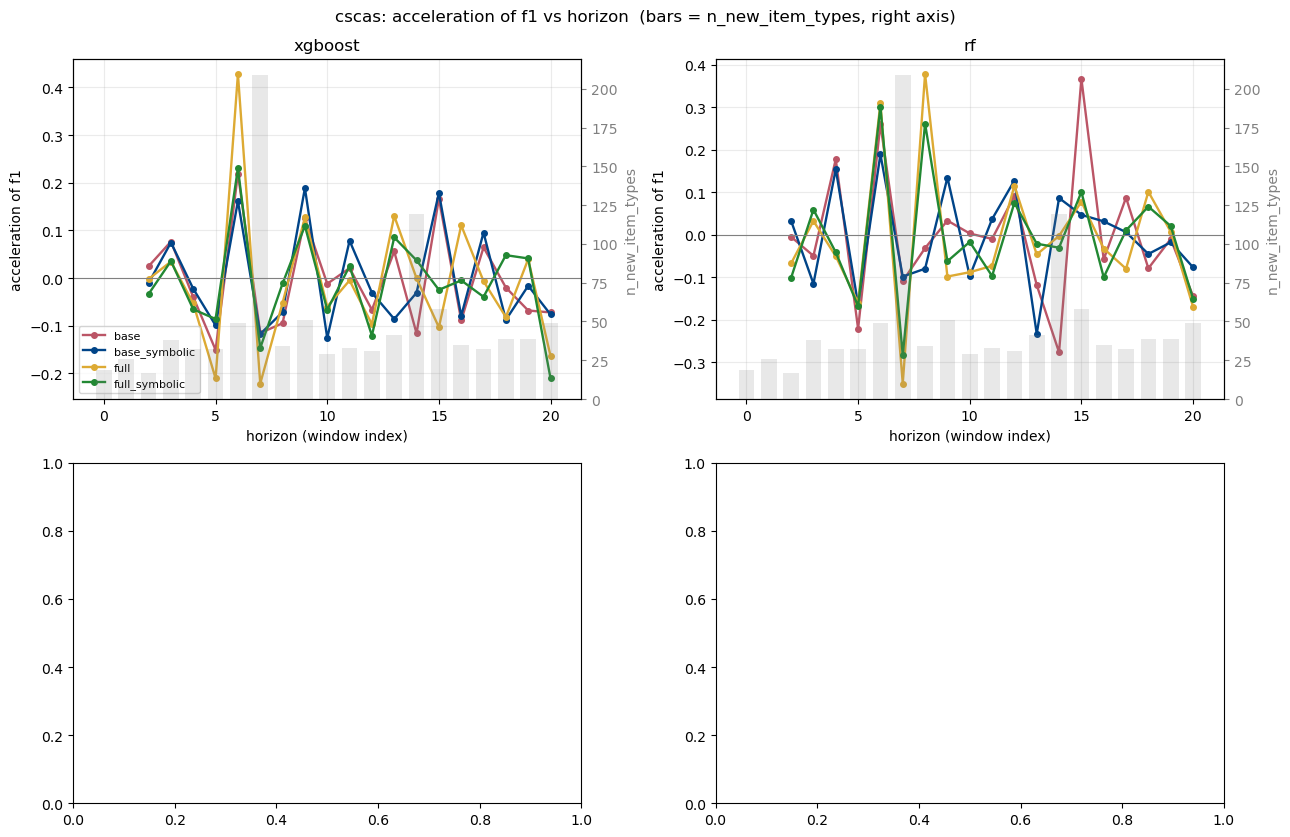

In [173]:
def plot_rate_vs_novelty(metric: str = None, kind: str = "velocity",
                         novelty_col: str = "n_new_item_types") -> None:
    metric = metric or PRIMARY_METRIC
    dyn = decay_dynamics(metric)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), squeeze=False)
    for ax, model in zip(axes.flat, MODELS):
        for fs in FEATURE_SETS:
            g = dyn[(dyn.feature_set == fs) & (dyn.model == model)]
            if g.empty:
                continue
            gg = g.groupby("horizon_window_index")[kind]
            ax.plot(gg.median().index, gg.median().values, "-o", ms=4, lw=1.7,
                    color=FEATURE_SET_COLOR[fs], label=fs_label(fs))
            if g.mining_setting.nunique() > 1:
                ax.fill_between(gg.median().index, gg.quantile(.25).values,
                                gg.quantile(.75).values, color=FEATURE_SET_COLOR[fs],
                                alpha=0.15, lw=0)
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(model)
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel(f"{kind} of {metric}")
        ax.grid(alpha=0.25)
        if HAS_NOVELTY and novelty_col in NOV:
            ax2 = ax.twinx()
            ax2.bar(NOV.index, NOV[novelty_col], color="grey", alpha=0.18, width=0.7, zorder=0)
            ax2.set_ylabel(novelty_col, color="grey")
            ax2.tick_params(axis="y", colors="grey")
    axes.flat[0].legend(fontsize=8, loc="lower left")
    fig.suptitle(f"{SCENARIO}: {kind} of {metric} vs horizon  "
                 f"(bars = {novelty_col}, right axis)")
    fig.tight_layout()
    save_fig(fig, "sec5", "rate_vs_novelty", kind, metric, f"gran={GRAN:g}")


plot_rate_vs_novelty(kind="velocity")
plot_rate_vs_novelty(kind="acceleration")

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec5_decay_vs_novelty_scatter_f1_gran=0.05.png


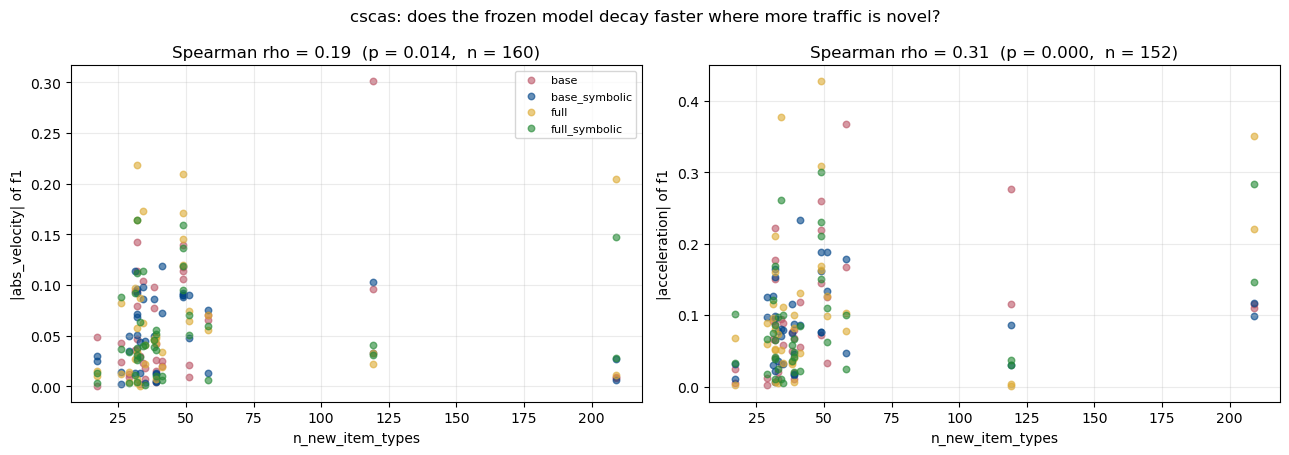

In [174]:
# Does the decay rate track novelty? Pool every (config, horizon>=1) point:
# |velocity| of the metric vs the window's novelty, coloured by feature set.
if HAS_NOVELTY:
    from scipy.stats import spearmanr
    metric = PRIMARY_METRIC
    dyn = decay_dynamics(metric).dropna(subset=["velocity"])
    dyn = dyn.merge(NOV.reset_index(), on="horizon_window_index", how="left")
    dyn["abs_velocity"] = dyn["velocity"].abs()

    xcol = "n_new_item_types"
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), squeeze=False)
    for ax, ycol in zip(axes[0], ["abs_velocity", "acceleration"]):
        d = dyn.dropna(subset=[ycol, xcol])
        for fs in FEATURE_SETS:
            f = d[d.feature_set == fs]
            ax.scatter(f[xcol], f[ycol].abs() if ycol == "acceleration" else f[ycol],
                       s=22, alpha=0.6, color=FEATURE_SET_COLOR[fs], label=fs_label(fs))
        rho, p = spearmanr(d[xcol], d[ycol].abs())
        ax.set_xlabel(xcol)
        ax.set_ylabel(f"|{ycol}| of {metric}")
        ax.set_title(f"Spearman rho = {rho:.2f}  (p = {p:.3f},  n = {len(d)})")
        ax.grid(alpha=0.25)
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"{SCENARIO}: does the frozen model decay faster where more traffic is novel?")
    fig.tight_layout()
    save_fig(fig, "sec5", "decay_vs_novelty_scatter", metric, f"gran={GRAN:g}")
else:
    print("no novelty columns in this run -- rerun the experiment to get the overlay")

  saved -> src/thesis/notebooks/experiments/img/exp1/cscas_sec5_lime_fidelity_gran=0.05.png


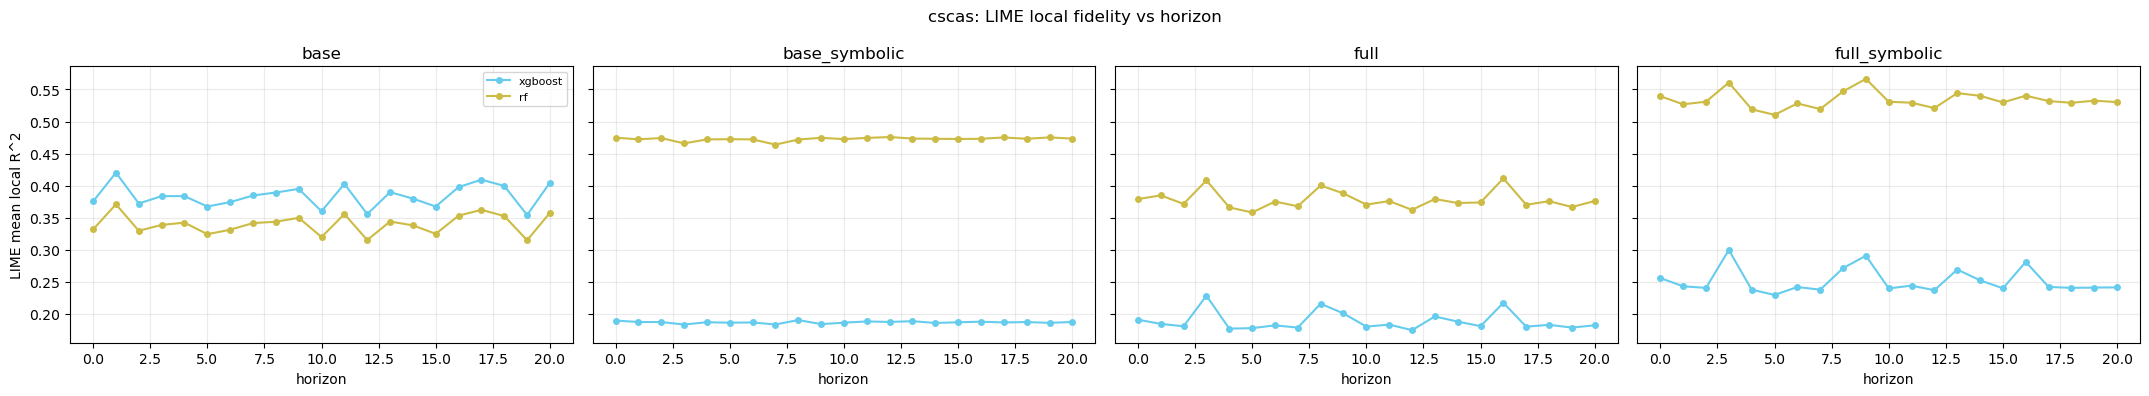

In [175]:
# LIME local fidelity (R^2 of the local linear surrogate) over the horizon --
# a drop means the decision surface is getting harder to approximate locally,
# independent of whether the signed weights are drifting (§4).
if not lime_fidelity.empty:
    lf = lime_fidelity[lime_fidelity.granularity == GRAN]
    fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(5.4 * len(FEATURE_SETS), 4),
                             squeeze=False, sharey=True)
    for ax, fs in zip(axes[0], FEATURE_SETS):
        for model in MODELS:
            g = lf[(lf.feature_set == fs) & (lf.model == model)]
            if g.empty:
                continue
            gg = g.groupby("horizon_window_index")["mean_fidelity"].median()
            ax.plot(gg.index, gg.values, "-o", ms=4, color=MODEL_COLOR[model], label=model)
        ax.set_title(fs_label(fs)); ax.set_xlabel("horizon"); ax.grid(alpha=0.25)
    axes[0][0].set_ylabel("LIME mean local R^2"); axes[0][0].legend(fontsize=8)
    fig.suptitle(f"{SCENARIO}: LIME local fidelity vs horizon")
    fig.tight_layout()
    save_fig(fig, "sec5", "lime_fidelity", f"gran={GRAN:g}")
else:
    print("no lime_fidelity rows")